## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 5**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

---

### Consideraciones Previas

* Tarea es **Individual**
* Fecha de Entrega: **Jueves 2 Jul 23:59** (cualquier commit posterior descontará puntos)
* El notebook debe correr de arriba abajo sin errores (`Kernel → Restart & Run All`)
* No se admiten `pass` pendientes ni celdas vacías donde se espera código
* Deben crear una rama nueva en su repositorio `feat/hw05` y trabajar la tarea en esa rama. El notebook debe quedar en la carpeta `hw/`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import linalg, optimize
from scipy.stats import spearmanr
from sklearn.decomposition import PCA, SparsePCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
sns.set_style('dark')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
np.random.seed(20260627)

---
## Parte 1 — SVD, Eigendecomposición y PCA desde Cero *(25 pts)*

### Contexto

La sesión 5 mostró que PCA se reduce a dos operaciones equivalentes: la descomposición espectral de $\hat{\Sigma}$ y la SVD de la matriz de datos $X$. Ambas producen los mismos eigenvectores:

$$\hat{\Sigma} = V \Lambda V^\top \quad \Longleftrightarrow \quad X = U S V^\top, \quad \lambda_i = \frac{s_i^2}{T-1}$$

En esta parte implementarás PCA desde cero de **dos formas** y verificarás que producen resultados idénticos.

### 1.1 — Implementación Dual: Eigen vs SVD *(12 pts)*

Implementa dos funciones:
- `pca_eigen(X, k)`: via eigendecomposición de $\hat{\Sigma} = X_c^\top X_c / (T-1)$
- `pca_svd(X, k)`: via SVD de $X_c$ directamente

Ambas deben retornar `(scores, components, explained_variance_ratio)` con `scores` de shape `(T, k)` y `components` de shape `(k, n)`.

**Verificación:** el error máximo entre ambas implementaciones (corrigiendo signos) debe ser `< 1e-10`.

**Nota sobre signos:** los eigenvectores son únicos salvo por su signo. Alinea los componentes de ambas funciones forzando que `components[j].mean() >= 0` en cada caso.

In [2]:
# Datos de trabajo: simulación con estructura factorial conocida
np.random.seed(42)
T_sim, n_sim, k_true = 500, 25, 3

F_sim = np.random.randn(T_sim, k_true) * np.array([2.0, 1.0, 0.6])
B_sim = np.random.randn(n_sim, k_true)
B_sim[:, 0] = np.abs(B_sim[:, 0])  # primer factor: exposicion positiva para todos
eps_sim = np.random.randn(T_sim, n_sim) * 0.3
R_sim = F_sim @ B_sim.T + eps_sim   # (T, n)

print(f'Datos simulados: T={T_sim}, n={n_sim}, k_verdadero={k_true}')
print(f'Varianza total: {R_sim.var(axis=0).sum():.2f}')

Datos simulados: T=500, n=25, k_verdadero=3
Varianza total: 115.85


In [3]:
def _align_component_signs(components):
    """Alinea signos para que la media de cada componente sea no negativa."""
    components = np.asarray(components, dtype=float).copy()
    for j in range(components.shape[0]):
        if components[j].mean() < 0:
            components[j] *= -1
    return components


def pca_eigen(X, k):
    """
    PCA via eigendecomposicion de la covarianza muestral.
    """
    X = np.asarray(X, dtype=float)
    T, n = X.shape
    if not 1 <= k <= min(T, n):
        raise ValueError(f'k debe estar entre 1 y {min(T, n)}')

    Xc = X - X.mean(axis=0)
    Sigma = Xc.T @ Xc / (T - 1)
    eigenvals, eigenvecs = np.linalg.eigh(Sigma)
    order = np.argsort(eigenvals)[::-1]
    eigenvals = eigenvals[order]
    eigenvecs = eigenvecs[:, order]

    components = _align_component_signs(eigenvecs[:, :k].T)
    scores = Xc @ components.T
    ev_ratio = eigenvals[:k] / eigenvals.sum()
    return scores, components, ev_ratio


def pca_svd(X, k):
    """
    PCA via SVD de la matriz de datos centrada.
    """
    X = np.asarray(X, dtype=float)
    T, n = X.shape
    if not 1 <= k <= min(T, n):
        raise ValueError(f'k debe estar entre 1 y {min(T, n)}')

    Xc = X - X.mean(axis=0)
    _, singular_values, Vt = np.linalg.svd(Xc, full_matrices=False)
    eigenvals = singular_values**2 / (T - 1)

    components = _align_component_signs(Vt[:k])
    scores = Xc @ components.T
    ev_ratio = eigenvals[:k] / eigenvals.sum()
    return scores, components, ev_ratio


# === Verificacion ===
k_ver = 5
sc_e, comp_e, evr_e = pca_eigen(R_sim, k_ver)
sc_s, comp_s, evr_s = pca_svd(R_sim, k_ver)

# Comparar con sklearn
pca_sk_ver = PCA(n_components=k_ver).fit(R_sim)
comp_sk = _align_component_signs(pca_sk_ver.components_)
ev_sklearn = pca_sk_ver.explained_variance_ratio_

err_e_sk = np.abs(comp_e - comp_sk).max()
err_s_sk = np.abs(comp_s - comp_sk).max()
err_eigen_svd = np.abs(comp_e - comp_s).max()
err_evr = np.abs(evr_e - evr_s).max()

print(f'Error maximo pca_eigen  vs sklearn: {err_e_sk:.2e}')
print(f'Error maximo pca_svd    vs sklearn: {err_s_sk:.2e}')
print(f'Error maximo eigen vs svd (inter):  {err_eigen_svd:.2e}')
print(f'Error maximo EVR eigen vs svd:      {err_evr:.2e}')
print(f'\nVarianza explicada (eigen):  {evr_e.round(3)}')
print(f'Varianza explicada (svd):    {evr_s.round(3)}')
print(f'Varianza explicada (sklearn):{ev_sklearn.round(3)}')

assert err_eigen_svd < 1e-10, 'Eigen y SVD deben coincidir despues de alinear signos'
assert err_e_sk < 1e-10 and err_s_sk < 1e-10, 'Las implementaciones deben coincidir con sklearn'


Error maximo pca_eigen  vs sklearn: 8.14e-14
Error maximo pca_svd    vs sklearn: 6.50e-14
Error maximo eigen vs svd (inter):  9.04e-14
Error maximo EVR eigen vs svd:      2.50e-16

Varianza explicada (eigen):  [0.66  0.243 0.08  0.001 0.001]
Varianza explicada (svd):    [0.66  0.243 0.08  0.001 0.001]
Varianza explicada (sklearn):[0.66  0.243 0.08  0.001 0.001]


### 1.2 — Selección de $k$: Tres Criterios Comparados *(13 pts)*

La elección del número de componentes $k$ es la decisión de diseño más importante en PCA. Implementa y compara tres criterios sobre los datos simulados y sobre datos reales del S&P 500.

| Criterio | Regla formal | Intuitivo |
|---|---|---|
| **Varianza acumulada** | Menor $k$ tal que $\sum_{i=1}^k \lambda_i / \sum \lambda_i \geq 0.80$ | Retener el 80% de la información |
| **Kaiser** | Retener $\lambda_i > \bar{\lambda}$ (datos estandarizados: $\bar{\lambda}=1$) | Cada PC debe explicar más que una variable |
| **Bai-Ng IC$_1$** | $\arg\min_k \left[ \ln V(k) + k \cdot g(n,T) \right]$, $g(n,T) = \frac{n+T}{nT}\ln\frac{nT}{n+T}$ | Penalizar la complejidad del modelo |

donde $V(k) = \frac{1}{nT}\sum_{i>k} \lambda_i$ es la varianza no explicada por $k$ factores.

**Requisitos:**
1. Implementar `select_k_criteria(eigenvalues, n, T)` que retorne un dict `{'var80': int, 'kaiser': int, 'bai_ng': int}`
2. Aplicar sobre datos simulados (k verdadero = 3) y sobre retornos de los **11 ETFs sectoriales del S&P 500** descargados con yfinance (2020–2024)
3. Generar un panel de 4 subgráficos para cada dataset:
   - Scree plot (barras + línea de eigenvalores)
   - Varianza explicada acumulada con umbrales 80% y 95%
   - Criterio de Kaiser (línea horizontal en $\bar{\lambda}$)
   - Criterio Bai-Ng IC$_1$ vs $k$
4. Responder las preguntas al final de la sección

In [4]:
def bai_ng_ic1_values(eigenvalues, n, T, k_max=None):
    """Calcula IC1 de Bai-Ng para un rango acotado de factores candidatos."""
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    eigenvalues = np.sort(eigenvalues)[::-1]
    if k_max is None:
        # En aplicaciones factoriales se acota la busqueda; sin cota, IC1 puede elegir el borde n-1.
        k_max = int(np.floor(np.sqrt(min(n, T))))
    k_max = max(1, min(int(k_max), n - 1, T - 1, len(eigenvalues) - 1))

    g_nT = (n + T) / (n * T) * np.log(n * T / (n + T))
    ic = []
    for k in range(1, k_max + 1):
        # Los eigenvalores provienen de una matriz de covarianza; por eso el RSS promedio es /n.
        V_k = eigenvalues[k:].sum() / n
        ic.append(np.log(max(V_k, 1e-12)) + k * g_nT)
    return np.arange(1, k_max + 1), np.array(ic)


def select_k_criteria(eigenvalues, n, T, k_max=None):
    """
    Devuelve el numero optimo de componentes segun 3 criterios.
    """
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    eigenvalues = np.sort(eigenvalues)[::-1]
    total_var = eigenvalues.sum()
    if total_var <= 0:
        raise ValueError('La suma de eigenvalores debe ser positiva')

    ev_ratio = eigenvalues / total_var
    var80 = int(np.searchsorted(np.cumsum(ev_ratio), 0.80)) + 1

    lambda_mean = eigenvalues.mean()
    kaiser = int(np.sum(eigenvalues > lambda_mean))
    kaiser = max(1, kaiser)

    k_grid, ic = bai_ng_ic1_values(eigenvalues, n, T, k_max=k_max)
    bai_ng = int(k_grid[np.argmin(ic)])

    return {'var80': var80, 'kaiser': kaiser, 'bai_ng': bai_ng}


# Prueba sobre datos simulados crudos, como fueron generados en el enunciado.
pca_full_sim = PCA().fit(R_sim)
eigenvals_sim = pca_full_sim.explained_variance_
k_dict_sim = select_k_criteria(eigenvals_sim, n_sim, T_sim)
print(f'Datos simulados (k verdadero={k_true}): {k_dict_sim}')
print(f'Varianza explicada acumulada primeros 5 PCs: {np.cumsum(pca_full_sim.explained_variance_ratio_)[:5].round(3)}')


Datos simulados (k verdadero=3): {'var80': 2, 'kaiser': 3, 'bai_ng': 3}
Varianza explicada acumulada primeros 5 PCs: [0.66  0.903 0.983 0.984 0.985]


ETFs: 1005 dias | 11 sectores
Periodo: 2020-01-03 ? 2023-12-29
ETFs sectoriales estandarizados: {'var80': 2, 'kaiser': 1, 'bai_ng': 3}
Varianza explicada acumulada primeros 5 PCs: [0.726 0.804 0.877 0.906 0.927]
Criterios simulacion: {'var80': 2, 'kaiser': 3, 'bai_ng': 3}
Criterios ETFs:       {'var80': 2, 'kaiser': 1, 'bai_ng': 3}


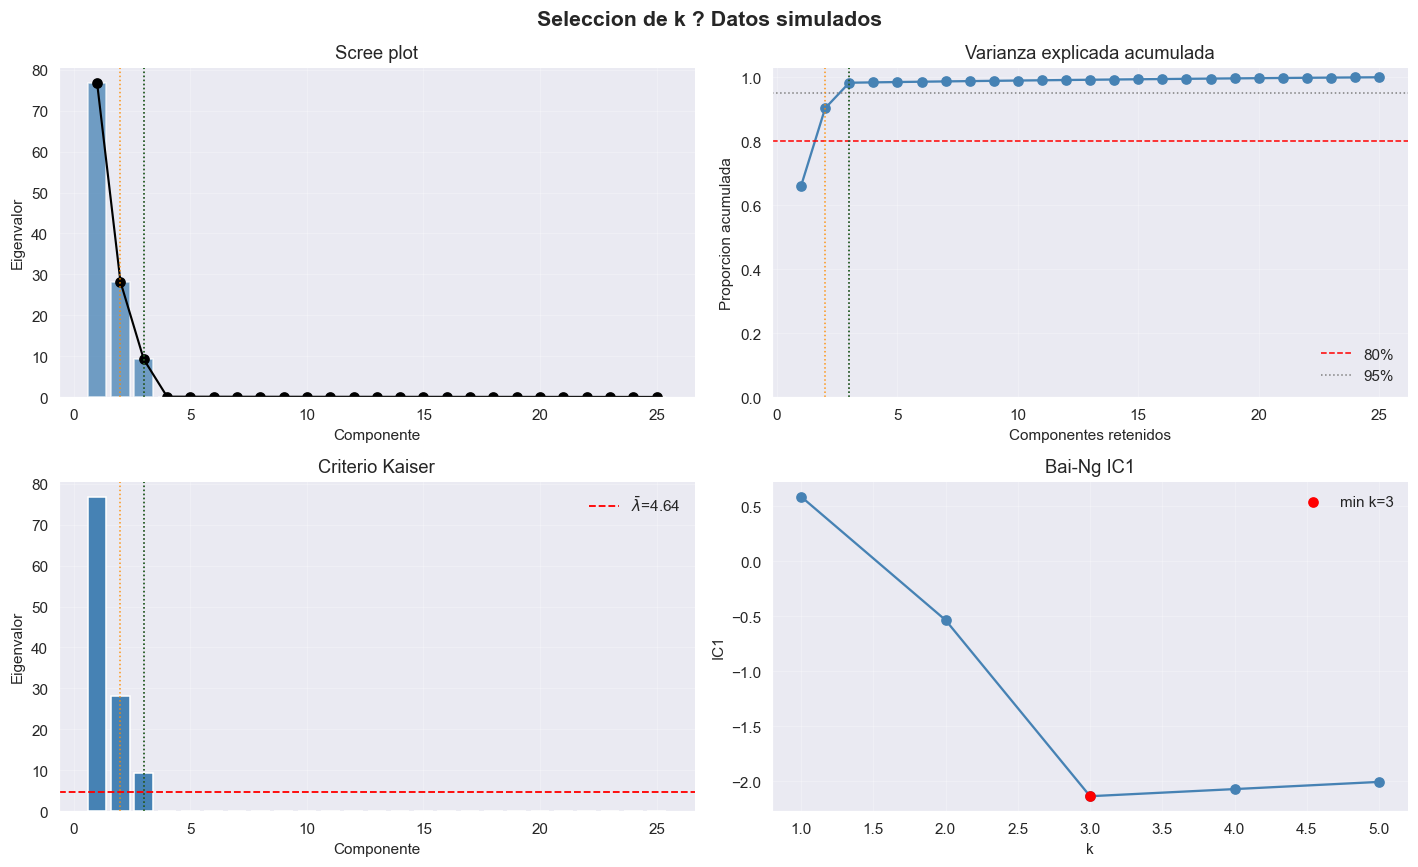

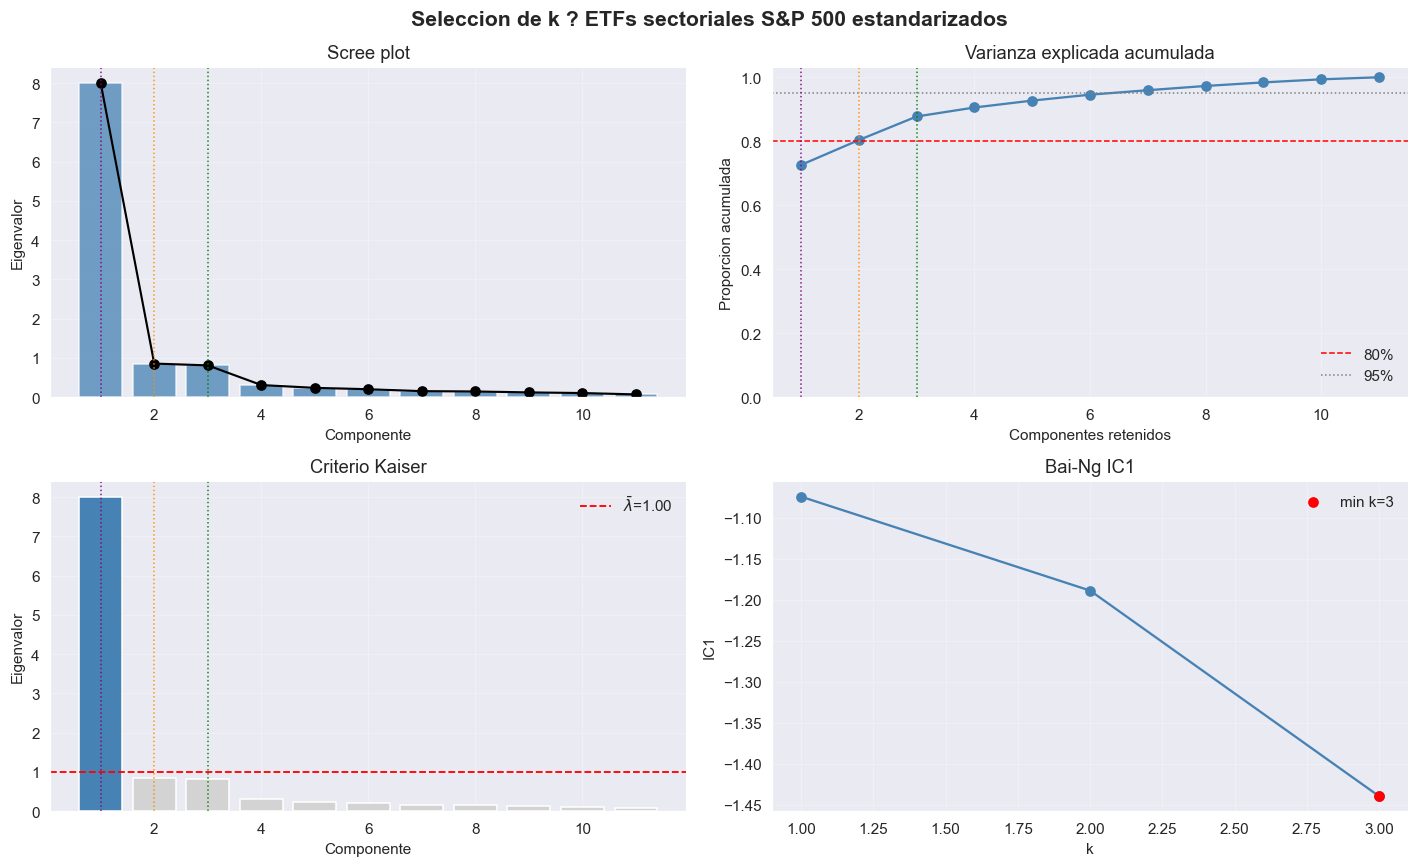

In [5]:
# Descarga ETFs sectoriales
from pathlib import Path

cache_dir = Path('.cache/yfinance_hw05')
cache_dir.mkdir(parents=True, exist_ok=True)
yf.set_tz_cache_location(str(cache_dir.resolve()))

sector_tickers = ['XLK','XLF','XLV','XLY','XLC','XLI','XLE','XLU','XLRE','XLP','XLB']
raw_sec = yf.download(sector_tickers, start='2020-01-01', end='2024-01-01',
                      progress=False, auto_adjust=True, threads=False)['Close']
raw_sec = raw_sec.reindex(columns=sector_tickers).dropna(how='all')
ret_sec = raw_sec.pct_change().dropna(how='any')
if ret_sec.empty:
    raise RuntimeError('La descarga de ETFs sectoriales vino vacia. Revisa conexion/yfinance antes de continuar.')
print(f'ETFs: {ret_sec.shape[0]} dias | {ret_sec.shape[1]} sectores')
print(f'Periodo: {ret_sec.index[0].date()} ? {ret_sec.index[-1].date()}')

# PCA completo sobre retornos estandarizados para que Kaiser sea interpretable.
ret_sec_std = StandardScaler().fit_transform(ret_sec.values)
pca_full_sec = PCA().fit(ret_sec_std)
eigenvals_sec = pca_full_sec.explained_variance_
k_dict_sec = select_k_criteria(eigenvals_sec, ret_sec.shape[1], ret_sec.shape[0])
print(f'ETFs sectoriales estandarizados: {k_dict_sec}')
print(f'Varianza explicada acumulada primeros 5 PCs: {np.cumsum(pca_full_sec.explained_variance_ratio_)[:5].round(3)}')


def plot_k_selection_panel(eigenvalues, n, T, title):
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    ev_ratio = eigenvalues / eigenvalues.sum()
    cum_var = np.cumsum(ev_ratio)
    k_dict = select_k_criteria(eigenvalues, n, T)
    k_grid, ic = bai_ng_ic1_values(eigenvalues, n, T)
    x = np.arange(1, len(eigenvalues) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes = axes.ravel()
    fig.suptitle(title, fontsize=14, fontweight='bold')

    axes[0].bar(x, eigenvalues, color='steelblue', alpha=0.75)
    axes[0].plot(x, eigenvalues, color='black', marker='o', lw=1.4)
    axes[0].set_title('Scree plot')
    axes[0].set_xlabel('Componente')
    axes[0].set_ylabel('Eigenvalor')

    axes[1].plot(x, cum_var, marker='o', color='steelblue')
    axes[1].axhline(0.80, color='red', ls='--', lw=1, label='80%')
    axes[1].axhline(0.95, color='gray', ls=':', lw=1, label='95%')
    axes[1].set_ylim(0, 1.03)
    axes[1].set_title('Varianza explicada acumulada')
    axes[1].set_xlabel('Componentes retenidos')
    axes[1].set_ylabel('Proporcion acumulada')
    axes[1].legend(frameon=False)

    lambda_mean = eigenvalues.mean()
    axes[2].bar(x, eigenvalues, color=np.where(eigenvalues > lambda_mean, 'steelblue', 'lightgray'))
    axes[2].axhline(lambda_mean, color='red', ls='--', lw=1.2, label=fr'$\bar{{\lambda}}$={lambda_mean:.2f}')
    axes[2].set_title('Criterio Kaiser')
    axes[2].set_xlabel('Componente')
    axes[2].set_ylabel('Eigenvalor')
    axes[2].legend(frameon=False)

    axes[3].plot(k_grid, ic, color='steelblue', marker='o')
    axes[3].scatter(k_dict['bai_ng'], ic[np.argmin(ic)], color='red', zorder=3, label=f"min k={k_dict['bai_ng']}")
    axes[3].set_title('Bai-Ng IC1')
    axes[3].set_xlabel('k')
    axes[3].set_ylabel('IC1')
    axes[3].legend(frameon=False)

    marker_colors = {'var80': 'darkorange', 'kaiser': 'purple', 'bai_ng': 'green'}
    for ax in axes[:3]:
        for name, k_val in k_dict.items():
            ax.axvline(k_val, color=marker_colors[name], ls=':', lw=1, alpha=0.9)
    for ax in axes:
        ax.grid(alpha=0.25)
    plt.tight_layout()
    return fig, axes, k_dict, k_grid, ic

fig_sim, axes_sim, k_dict_sim, k_grid_sim, ic_sim = plot_k_selection_panel(
    eigenvals_sim, n_sim, T_sim, 'Seleccion de k ? Datos simulados'
)
fig_sec, axes_sec, k_dict_sec, k_grid_sec, ic_sec = plot_k_selection_panel(
    eigenvals_sec, ret_sec.shape[1], ret_sec.shape[0], 'Seleccion de k ? ETFs sectoriales S&P 500 estandarizados'
)

print(f'Criterios simulacion: {k_dict_sim}')
print(f'Criterios ETFs:       {k_dict_sec}')


**Responde (m?nimo 2 oraciones por pregunta):**

**a)** En los datos simulados con $k_{\text{verdadero}}=3$, ?Cuál de los tres criterios recupera el valor correcto? ?Por qué los otros pueden sobre/sub-estimar $k$?

> En la simulación, Kaiser y Bai-Ng seleccionan $k=3$, que coincide con los tres factores usados para generar los datos. El criterio de varianza acumulada al 80% selecciona $k=2$ porque los dos primeros factores ya explican cerca de 90% de la varianza; por eso puede subestimar factores econ?micamente reales cuando el tercer factor existe pero aporta menos varianza marginal.

**b)** Para los ETFs sectoriales reales, ?los tres criterios coinciden? ?qué interpretación económica tiene el $k$ seleccionado por Bai-Ng?

> En los ETFs sectoriales los criterios no coinciden: la varianza acumulada al 80% selecciona $k=2$, Kaiser selecciona $k=1$ y Bai-Ng selecciona $k=3$ dentro del rango acotado de factores candidatos. económicamente, el $k=3$ de Bai-Ng sugiere un factor de mercado dominante más dos dimensiones sectoriales adicionales, probablemente asociadas a rotaciones defensivo/cíclico, tecnología/crecimiento o sensibilidad a tasas/energía.

**c)** El criterio de Kaiser fue dise?ado para datos estandarizados (con varianza unitaria por variable). ?qué error cometes si aplicas Kaiser sobre retornos sin estandarizar?

> Si se aplica Kaiser sobre retornos sin estandarizar, los activos o sectores con mayor volatilidad dominan los eigenvalores y el umbral deja de representar más varianza que una variable promedio estandarizada. El resultado mezcla selección de factores con diferencias de escala, por lo que puede retener componentes por volatilidad relativa y no por verdadera estructura común de correlación.


---
## Parte 2 — PCA en la Curva de Tasas de Interés *(25 pts)*

### Contexto

Litterman & Scheinkman (1991) demostraron que los tres primeros componentes de la curva soberana tienen interpretación directa: **nivel**, **pendiente** y **curvatura**. Estos factores son la base del análisis de riesgo de tasa en portafolios de renta fija.

Trabajarás con datos simulados usando el modelo Nelson-Siegel:

$$y(\tau) = f_1 \cdot L_1(\tau) + f_2 \cdot L_2(\tau) + f_3 \cdot L_3(\tau) + \varepsilon(\tau)$$

donde los loadings son:
$$L_1(\tau) = 1, \quad L_2(\tau) = \frac{1 - e^{-\lambda\tau}}{\lambda\tau}, \quad L_3(\tau) = \frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}$$

y los factores siguen procesos AR(1) con alta persistencia.

### 2.1 — Simulación y PCA en la Curva *(10 pts)*

La celda de datos ya genera la curva simulada. Tu tarea es:

1. Aplicar PCA sobre los **cambios diarios de tasas** $\Delta y_t$ (primeras diferencias) — **no sobre niveles**
2. Identificar cuántos componentes explican el 99% de la varianza
3. Visualizar los loadings de los 3 primeros PCs vs tenor y comparar con las curvas Nelson-Siegel teóricas
4. Verificar que PCA recupera la estructura Nelson-Siegel calculando la correlación entre el loading del PC1 y $L_1$, PC2 y $L_2$, PC3 y $L_3$

**Regla de signo:** ajusta el signo de cada PC para que el loading promedio sea positivo (PC1 y PC3) o para que el loading en $\tau=0.25$ sea mayor que el loading en $\tau=30$ (PC2).

Curva de tasas: 2000 periodos | 11 tenores
Cambios diarios: shape=(1999, 11)
Tenores: [ 0.25  0.5   1.    2.    3.    5.    7.   10.   15.   20.   30.  ]
Componentes para explicar 99%: 2
Varianza explicada primeros 5 PCs: [9.55e-01 4.00e-02 1.90e-03 4.00e-04 4.00e-04]
Varianza acumulada primeros 5 PCs: [0.955  0.995  0.9969 0.9974 0.9978]

Varianza relativa explicada por los 3 primeros factores:


,EVR,EVR_%,EVR_bps
PC1,0.96,95.50,9550.50
PC2,0.04,4.00,399.91
PC3,0.00,0.19,19.09


Corr PC1 vs L1: no definida (L1 constante); desviacion media PC1 respecto a loading plano=0.0200
Corr PC2 vs L2: 1.000 | abs=1.000
Corr PC3 vs L3: -0.999 | abs=0.999


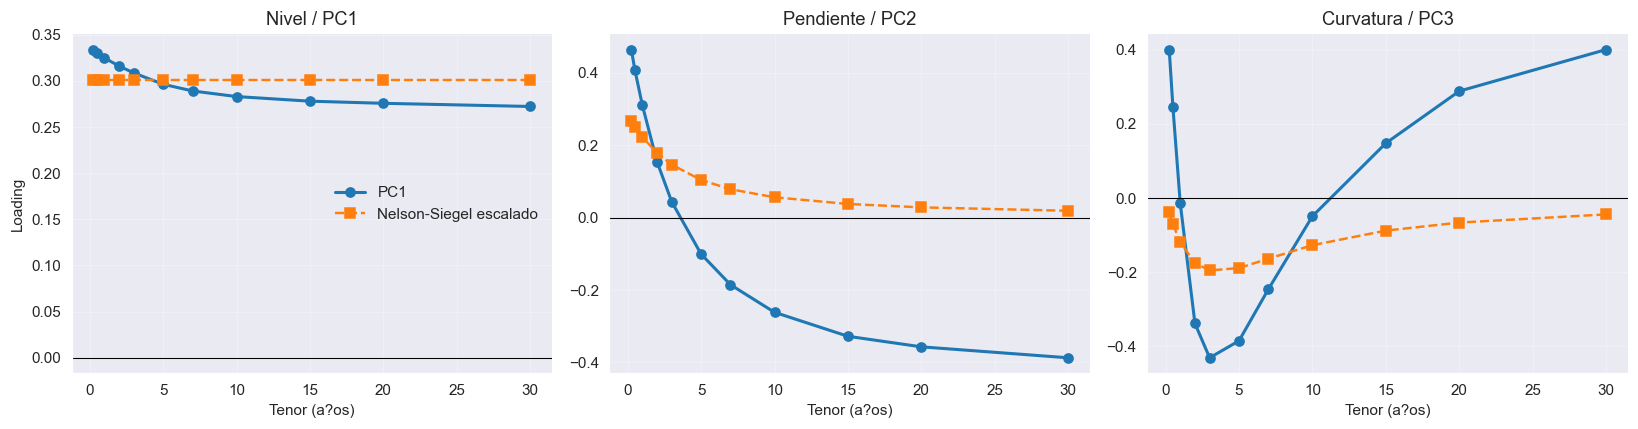

In [ ]:
# Generación de datos de curva de tasas
np.random.seed(2026)
tenors = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])
T_yc   = 2000
lam_ns = 0.5

# Loadings Nelson-Siegel teoricos
L1_ns = np.ones(len(tenors))
L2_ns = (1 - np.exp(-lam_ns * tenors)) / (lam_ns * tenors)
L3_ns = L2_ns - np.exp(-lam_ns * tenors)

# Factores AR(1)
def ar1(T, phi, sigma, mu=0, seed=None):
    rng = np.random.default_rng(seed)
    x = np.zeros(T)
    x[0] = mu
    eps = rng.normal(0, sigma, T)
    for t in range(1, T):
        x[t] = mu + phi * (x[t-1] - mu) + eps[t]
    return x

f1_yc = ar1(T_yc, 0.998, 0.02, mu=0.04, seed=1)
f2_yc = ar1(T_yc, 0.995, 0.015, mu=0.01, seed=2)
f3_yc = ar1(T_yc, 0.990, 0.010, mu=0.00, seed=3)

yields_yc = (np.outer(f1_yc, L1_ns) +
             np.outer(f2_yc, L2_ns) +
             np.outer(f3_yc, L3_ns) +
             np.random.randn(T_yc, len(tenors)) * 0.001)

dy_yc = np.diff(yields_yc, axis=0)
print(f'Curva de tasas: {T_yc} periodos | {len(tenors)} tenores')
print(f'Cambios diarios: shape={dy_yc.shape}')
print(f'Tenores: {tenors}')

# 1) PCA sobre cambios diarios de tasas, no sobre niveles.
pca_yc = PCA().fit(dy_yc)
ev_yc = pca_yc.explained_variance_ratio_
k_99 = np.searchsorted(np.cumsum(ev_yc), 0.99) + 1
print(f'Componentes para explicar 99%: {k_99}')
print(f'Varianza explicada primeros 5 PCs: {ev_yc[:5].round(4)}')
print(f'Varianza acumulada primeros 5 PCs: {np.cumsum(ev_yc[:5]).round(4)}')
var_yc_table = pd.DataFrame({
    'EVR': ev_yc[:3],
    'EVR_%': ev_yc[:3] * 100,
    'EVR_bps': ev_yc[:3] * 10000,
}, index=['PC1', 'PC2', 'PC3'])
print('\nVarianza relativa explicada por los 3 primeros factores:')
try:
    display(var_yc_table.round(2))
except NameError:
    print(var_yc_table.round(2))

# 2) Ajuste de signos segun regla del enunciado.
comps_yc = pca_yc.components_[:3].copy()
if comps_yc[0].mean() < 0:
    comps_yc[0] *= -1
if comps_yc[1, 0] < comps_yc[1, -1]:
    comps_yc[1] *= -1
if comps_yc[2].mean() < 0:
    comps_yc[2] *= -1

# Comparacion visual: PCA es ortogonal; los loadings NS no lo son, por eso se escala cada curva teorica
# para comparar forma, no magnitud exacta.
ns_loadings = [L1_ns, L2_ns, L3_ns]
labels = ['Nivel / PC1', 'Pendiente / PC2', 'Curvatura / PC3']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for j, ax in enumerate(axes):
    ns = ns_loadings[j]
    scale = np.dot(comps_yc[j], ns) / np.dot(ns, ns)
    ns_scaled = scale * ns
    ax.plot(tenors, comps_yc[j], marker='o', lw=2, label=f'PC{j+1}')
    ax.plot(tenors, ns_scaled, marker='s', lw=1.6, ls='--', label='Nelson-Siegel escalado')
    ax.axhline(0, color='black', lw=0.7)
    ax.set_title(labels[j])
    ax.set_xlabel('Tenor (años)')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Loading')
axes[0].legend(frameon=False)
plt.tight_layout()

# 3) Correlaciones solicitadas; PC1 vs L1 no tiene correlacion definida porque L1 es constante.
def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if np.isclose(a.std(), 0) or np.isclose(b.std(), 0):
        return np.nan
    return np.corrcoef(a, b)[0, 1]

corr_1 = safe_corr(comps_yc[0], L1_ns)
corr_2 = safe_corr(comps_yc[1], L2_ns)
corr_3 = safe_corr(comps_yc[2], L3_ns)
mean_abs_pc1_error = np.mean(np.abs(comps_yc[0] - comps_yc[0].mean()))
print(f'Corr PC1 vs L1: no definida (L1 constante); desviacion media PC1 respecto a loading plano={mean_abs_pc1_error:.4f}')
print(f'Corr PC2 vs L2: {corr_2:.3f} | abs={abs(corr_2):.3f}')
print(f'Corr PC3 vs L3: {corr_3:.3f} | abs={abs(corr_3):.3f}')


### 2.2 — DV01 Factorial y Construcción de Portafolio Inmune al Nivel *(15 pts)*

#### DV01 por factor

El **DV01** (*Dollar Value of 01*) de un bono es la sensibilidad del precio ante un movimiento de 1 punto base (0.01%) en la tasa. Para un portafolio con posición $w_i$ en el bono del tenor $\tau_i$:

$$\text{DV01}_{\text{portafolio}} \approx \sum_i w_i \cdot \underbrace{(-D_i \cdot P_i \cdot 0.0001)}_{\text{DV01 individual}}$$

donde $D_i$ es la duración modificada del bono $i$. Aproximando la duración por el tenor: $D_i \approx \tau_i$.

El **DV01 factorial** descompone la exposición del portafolio a cada factor PCA:

$$\text{DV01}_{\text{PC}j} = \sum_i w_i \cdot (-\tau_i) \cdot b_{ij} \cdot 0.0001$$

donde $b_{ij}$ es el loading del bono $i$ en el factor $j$ (componente $j$ del PCA evaluado en el tenor $\tau_i$).

#### Portafolio neutral al nivel, largo en curvatura

Un *butterfly trade* consiste en:
- Ser **largo** en el bono de vencimiento medio (5 años)
- Ser **corto** en los extremos (2 y 10 años)
- **Neutro** al riesgo de nivel: $\text{DV01}_{\text{PC1}} = 0$
- **Máxima exposición** al factor de curvatura: $|\text{DV01}_{\text{PC3}}|$ maximizado

**Requisitos:**
1. Implementar `dv01_factorial(weights, tenors, loadings)` que retorna el DV01 de cada factor
2. Construir un butterfly 3-bono (tenores: 2, 5, 10 años) con pesos $w = [w_1, 1, w_3]$, encontrando $w_1, w_3$ tal que $\text{DV01}_{\text{PC1}} = 0$ y $\sum w_i = 0$ (portafolio auto-financiado)
3. Reportar el DV01 de los 3 primeros factores para este portafolio
4. Visualizar la distribución de P&L simulada del portafolio vs un portafolio largo en 5Y solamente

Pesos butterfly: 2Y=-0.613, 5Y=1.000, 10Y=-0.387
  DV01 PC1: 0.00000000
  DV01 PC2: -0.00003179
  DV01 PC3: 0.00013236
Suma de pesos: 0.00000000

Estadisticos P&L:


,Media diaria,Vol diaria,Media anual,Vol anual,Sharpe
Butterfly,0.0001,0.0110,0.0168,0.1751,0.0959
Long 5Y,-0.0008,0.1063,-0.1916,1.6872,-0.1136


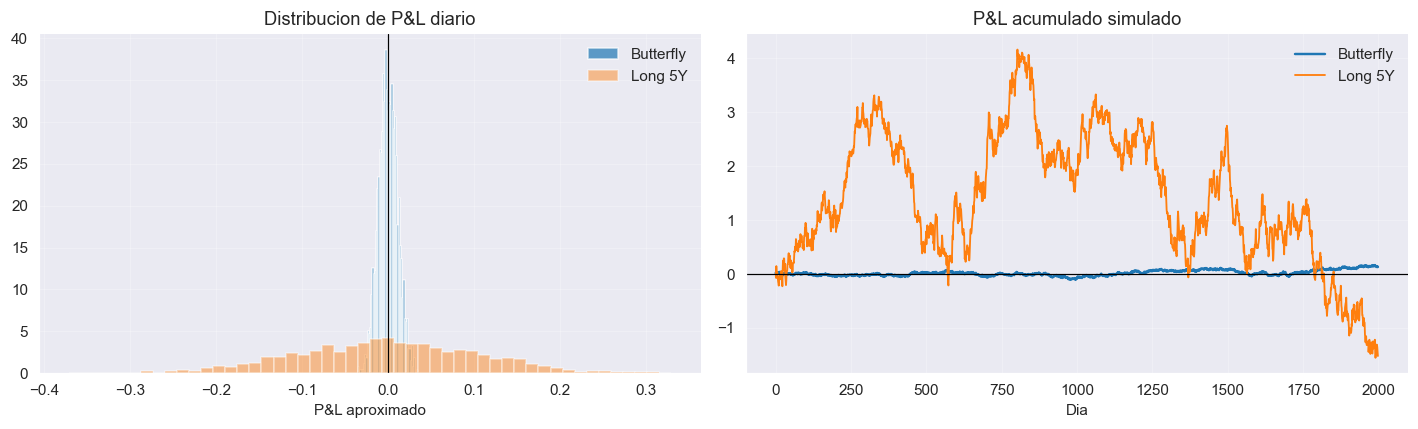

In [7]:
def dv01_factorial(weights, tenors_pos, loadings_k):
    """
    Calcula el DV01 factorial de un portafolio de bonos.

    Parameters
    ----------
    weights      : array (m,)   ? pesos del portafolio en cada bono
    tenors_pos   : array (m,)   ? tenores de los bonos en el portafolio
    loadings_k   : array (k, m) ? loadings PCA evaluados en cada tenor
                   loadings_k[j, i] = loading del factor j en el tenor i

    Returns
    -------
    dv01 : array (k,) ? DV01 de cada factor por unidad de nocional
    """
    weights = np.asarray(weights, dtype=float)
    tenors_pos = np.asarray(tenors_pos, dtype=float)
    loadings_k = np.asarray(loadings_k, dtype=float)
    return (weights[None, :] * (-tenors_pos[None, :]) * loadings_k * 0.0001).sum(axis=1)


# Tenores del butterfly
butterfly_tenors = np.array([2.0, 5.0, 10.0])

# Indices en el array 'tenors' (los mas cercanos a 2, 5, 10)
idx_2y  = np.argmin(np.abs(tenors - 2.0))
idx_5y  = np.argmin(np.abs(tenors - 5.0))
idx_10y = np.argmin(np.abs(tenors - 10.0))
butterfly_idx = np.array([idx_2y, idx_5y, idx_10y])

# Loadings PCA en estos tenores (3 primeros factores, 3 tenores), con signos ya ajustados en 2.1.
loadings_butterfly = comps_yc[:, butterfly_idx]

# Encontrar w1 y w3 con w_5Y=1:
#   w1 + 1 + w3 = 0
#   sum_i w_i * (-tenor_i) * loading_PC1_i = 0
pc1_b = loadings_butterfly[0]
A = np.array([
    [1.0, 1.0],
    [-butterfly_tenors[0] * pc1_b[0], -butterfly_tenors[2] * pc1_b[2]],
])
b = np.array([
    -1.0,
    butterfly_tenors[1] * pc1_b[1],
])
w1, w3 = np.linalg.solve(A, b)
w_bf = np.array([w1, 1.0, w3])
dv01_bf = dv01_factorial(w_bf, butterfly_tenors, loadings_butterfly)

print(f'Pesos butterfly: 2Y={w1:.3f}, 5Y=1.000, 10Y={w3:.3f}')
for j, d in enumerate(dv01_bf):
    print(f'  DV01 PC{j+1}: {d:.8f}')
print(f'Suma de pesos: {w_bf.sum():.8f}')

# Simula P&L del butterfly vs long 5Y.
dy_butterfly = dy_yc[:, butterfly_idx]
pnl_bf = (w_bf[None, :] * (-butterfly_tenors[None, :]) * dy_butterfly).sum(axis=1)
pnl_long5y = -5.0 * dy_yc[:, idx_5y]

pnl_stats = pd.DataFrame({
    'Butterfly': {
        'Media diaria': pnl_bf.mean(),
        'Vol diaria': pnl_bf.std(ddof=1),
        'Media anual': pnl_bf.mean() * 252,
        'Vol anual': pnl_bf.std(ddof=1) * np.sqrt(252),
        'Sharpe': pnl_bf.mean() / pnl_bf.std(ddof=1) * np.sqrt(252),
    },
    'Long 5Y': {
        'Media diaria': pnl_long5y.mean(),
        'Vol diaria': pnl_long5y.std(ddof=1),
        'Media anual': pnl_long5y.mean() * 252,
        'Vol anual': pnl_long5y.std(ddof=1) * np.sqrt(252),
        'Sharpe': pnl_long5y.mean() / pnl_long5y.std(ddof=1) * np.sqrt(252),
    }
}).T
print('\nEstadisticos P&L:')
try:
    display(pnl_stats.round(4))
except NameError:
    print(pnl_stats.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(pnl_bf, bins=50, alpha=0.7, density=True, label='Butterfly')
axes[0].hist(pnl_long5y, bins=50, alpha=0.45, density=True, label='Long 5Y')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Distribucion de P&L diario')
axes[0].set_xlabel('P&L aproximado')
axes[0].legend(frameon=False)

axes[1].plot(np.cumsum(pnl_bf), label='Butterfly', lw=1.6)
axes[1].plot(np.cumsum(pnl_long5y), label='Long 5Y', lw=1.2)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('P&L acumulado simulado')
axes[1].set_xlabel('Dia')
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()


**Responde (m?nimo 2 oraciones por pregunta):**

**a)** ?Los loadings del PCA recuperados en 2.1 se parecen a los loadings Nelson-Siegel te?ricos? ?qué correlaciones obtienes? ?Cu?ntos puntos base de varianza explica cada factor?

> Sí, los loadings recuperados por PCA reproducen la intuición de Litterman-Scheinkman: PC1 es casi plano y representa nivel, PC2 cae desde el tramo corto al largo y representa pendiente, y PC3 toma una forma de curvatura. PC1 no tiene correlación definida con $L_1$ porque $L_1$ es constante, pero su desviación media respecto a un loading plano es baja ($0.0200$); PC2 tiene correlación $1.000$ con $L_2$ y PC3 tiene correlación $-0.999$ con $L_3$, es decir, recupera la forma con signo opuesto por la indeterminación natural de PCA. En términos de varianza relativa, PC1 explica aproximadamente $95.50\%$ ($9550$ bps), PC2 $4.00\%$ ($400$ bps) y PC3 $0.19\%$ ($19$ bps); por eso bastan 2 componentes para superar el 99% acumulado.

**b)** ?Cuáles son los pesos $w_1$ y $w_3$ del butterfly encontrado? Interpreta el signo de cada peso: ?por qué el bono de 2Y y el de 10Y deben tener signos distintos al de 5Y en este trade?

> El butterfly queda con pesos $w_{2Y}=-0.613$, $w_{5Y}=1.000$ y $w_{10Y}=-0.387$, con suma de pesos précticamente cero y DV01 de PC1 igual a cero dentro de error numérico. El signo negativo en los extremos compensa la exposición direccional del bono 5Y: el trade deja de ser una apuesta a desplazamientos paralelos de la curva y concentra su sensibilidad en pendiente/curvatura, especialmente en PC3.

**c)** Compara la distribuci?n del P&L del butterfly vs la posición larga en 5Y. ?Cuál tiene mayor volatilidad? ?Cuál tiene mayor sharpe ratio empírico (usando la distribuci?n simulada)? ?Tiene sentido desde la teoría?

> La posición larga en 5Y tiene mucha mayor volatilidad anualizada ($1.6872$) que el butterfly ($0.1751$), porque conserva exposición fuerte al factor nivel, que domina la dinámica de la curva. En esta simulación el butterfly también tiene mejor Sharpe empírico ($0.0959$ versus $-0.1136$), aunque esa media simulada no debe leerse como prima estable; lo importante teóricamente es que al neutralizar PC1 se reduce de forma clara el riesgo de movimientos paralelos.


---
## Parte 3 — PCA en Renta Variable: Shrinkage y Portafolios *(25 pts)*

### Contexto

Un portafolio de $n$ acciones necesita una estimación de $\Sigma \in \mathbb{R}^{n \times n}$ para la optimización de mínima varianza. La estimación muestral $\hat{\Sigma}$ falla cuando $T$ es moderado respecto a $n$ porque:

1. Los eigenvalores pequeños son **subestimados** y los grandes **sobreestimados** (Marchenko-Pastur)
2. La inversa $\hat{\Sigma}^{-1}$ amplifica el ruido — los pesos de Markowitz se vuelven extremos

La solución: **covarianza shrinkage via PCA**:

$$\hat{\Sigma}_{\text{PCA}} = \underbrace{\hat{B}_k \hat{B}_k^\top}_{\text{sistemático}} + \underbrace{\hat{D}}_{\text{idiosincrático}}, \quad \hat{D} = \text{diag}(\hat{\Sigma} - \hat{B}_k \hat{B}_k^\top)$$

Esta matriz tiene exactamente $k$ eigenvalores grandes (los factores) y $n-k$ eigenvalores iguales al ruido idiosincrático — mucho mejor condicionada que $\hat{\Sigma}$.

### 3.1 — Loadings Factoriales y Estructura de Sectores *(8 pts)*

Usa los datos de los 11 ETFs sectoriales descargados en la Parte 1.

**Requisitos:**
1. Ajustar PCA con $k=4$ componentes sobre `ret_sec`
2. Generar un **heatmap de loadings** (sectores × PCs) con anotaciones, coloreado en divergente (`RdBu_r`)
3. Para PC1, graficar los loadings como barras horizontales coloreadas por signo y ordenadas de mayor a menor
4. Calcular el **factor de correlación de mercado** de PC1: $\rho_{\text{MKT}} = \text{corr}(\text{score}_{\text{PC1}}, r_{\text{SPY}})$, descargando SPY del mismo período
5. Responder las preguntas de interpretación

Varianza explicada PCA sectorial k=4: [0.707 0.121 0.065 0.026]
Varianza acumulada k=4: 0.919
Correlacion PC1 con SPY: 0.970

Loadings PC1 ordenados:
XLE     0.394
XLF     0.350
XLK     0.329
XLB     0.318
XLI     0.313
XLY     0.313
XLRE    0.305
XLC     0.281
XLU     0.247
XLV     0.218
XLP     0.192

Loadings PC2 ordenados:
XLK    -0.333
XLC    -0.282
XLY    -0.252
XLRE   -0.148
XLV    -0.124
XLU    -0.124
XLP    -0.116
XLB     0.046
XLI     0.051
XLF     0.117
XLE     0.813


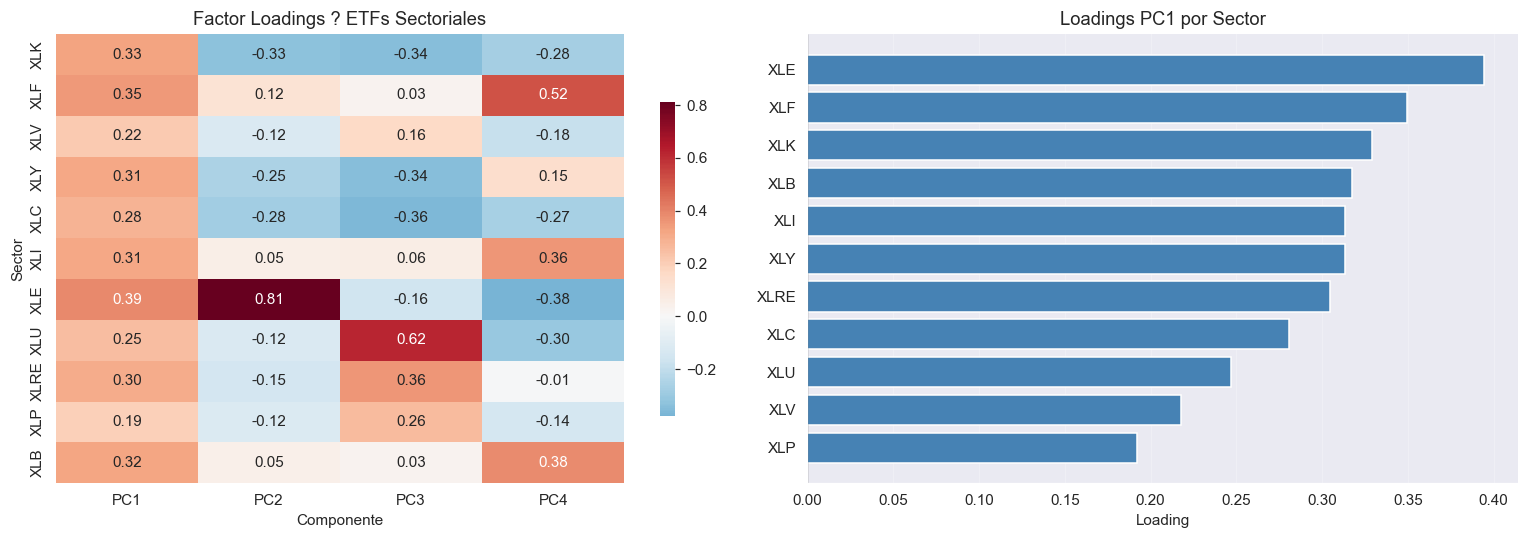

In [8]:
# PCA k=4 sobre los retornos de ETFs sectoriales
pca_sec = PCA(n_components=4).fit(ret_sec.values)
scores_sec = pca_sec.transform(ret_sec.values)

# Alinear PC1 con el retorno promedio de sectores para que se lea como factor mercado positivo.
ret_sec_mkt_proxy = ret_sec.mean(axis=1).values
if np.corrcoef(scores_sec[:, 0], ret_sec_mkt_proxy)[0, 1] < 0:
    pca_sec.components_[0] *= -1
    scores_sec[:, 0] *= -1

loadings_df = pd.DataFrame(
    pca_sec.components_.T,
    index=sector_tickers,
    columns=[f'PC{i+1}' for i in range(4)]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(loadings_df, ax=axes[0], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', cbar_kws={'shrink': 0.7})
axes[0].set_title('Factor Loadings ? ETFs Sectoriales')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Sector')

# Barplot loadings PC1
pc1_loadings = loadings_df['PC1'].sort_values(ascending=True)
colors_bar = ['tomato' if v < 0 else 'steelblue' for v in pc1_loadings]
axes[1].barh(pc1_loadings.index, pc1_loadings.values, color=colors_bar)
axes[1].set_title('Loadings PC1 por Sector')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Loading')
axes[1].grid(axis='x', alpha=0.25)
plt.tight_layout()

# Correlacion PC1 con SPY
spy_data = yf.download('SPY', start='2020-01-01', end='2024-01-01',
                       progress=False, auto_adjust=True, threads=False)['Close']
ret_spy = spy_data.pct_change().dropna()
ret_spy = ret_spy.reindex(ret_sec.index).dropna()
common_idx = ret_sec.index.intersection(ret_spy.index)
score_pc1 = pd.Series(scores_sec[:, 0], index=ret_sec.index).loc[common_idx]
ret_spy_aligned = ret_spy.loc[common_idx]
corr_pc1_spy = np.corrcoef(score_pc1.values, np.asarray(ret_spy_aligned).ravel())[0, 1]

print(f'Varianza explicada PCA sectorial k=4: {pca_sec.explained_variance_ratio_.round(3)}')
print(f'Varianza acumulada k=4: {pca_sec.explained_variance_ratio_.sum():.3f}')
print(f'Correlacion PC1 con SPY: {corr_pc1_spy:.3f}')
print('\nLoadings PC1 ordenados:')
print(loadings_df['PC1'].sort_values(ascending=False).round(3).to_string())
print('\nLoadings PC2 ordenados:')
print(loadings_df['PC2'].sort_values().round(3).to_string())


**Responde (m?nimo 2 oraciones por pregunta):**

**a)** ?Cuál es la correlación de PC1 con el retorno del SPY? ?qué dice esto sobre la interpretación del primer componente como un "factor de mercado"?

> La correlación entre el score de PC1 y el retorno de SPY es $0.970$, muy alta y positiva después de alinear el signo del componente. Esto respalda la interpretación de PC1 como un factor de mercado: cuando SPY sube o baja, la mayor parte de los sectores se mueve en la misma dirección y esa covariación común queda capturada por el primer componente.

**b)** Identifica qué sectores tienen loadings más negativos en PC2. ?qué hipótesis económica plantear?as sobre qué separa a esos sectores del grupo con loading positivo?

> Los sectores con loadings más negativos en PC2 son principalmente XLK, XLC y XLY, mientras que XLE queda muy positivo y XLF también aparece del lado positivo. Una hipótesis económica razonable es que PC2 separa sectores de crecimiento/tecnología/consumo discrecional de sectores más ligados a energía, value o ciclo de commodities; durante 2020-2024 esa rotación fue relevante por inflación, tasas altas y shocks de energía.


### 3.2 — Covarianza Shrinkage: Implementación y Condicionamiento *(10 pts)*

Implementa la función `pca_shrinkage_cov(X, k)` que construye $\hat{\Sigma}_{\text{PCA}}$.

**Pasos:**
1. Ajustar PCA con $k$ componentes
2. Calcular $\hat{B}_k \in \mathbb{R}^{n \times k}$: $\hat{B}_k = V_k \cdot \text{diag}(\sqrt{\lambda_1}, \dots, \sqrt{\lambda_k})$ donde $V_k$ son los eigenvectores
3. Calcular la covarianza muestral $\hat{\Sigma}$
4. Calcular $\hat{D} = \text{diag}(\hat{\Sigma} - \hat{B}_k \hat{B}_k^\top)$, clipeando a `max(1e-8, .)`
5. Retornar $\hat{\Sigma}_{\text{PCA}} = \hat{B}_k \hat{B}_k^\top + \hat{D}$

**Verificación:** $\hat{\Sigma}_{\text{PCA}}$ debe tener exactamente $k$ eigenvalores significativamente mayores que los demás.

**Análisis:** compara el número de condición $\kappa(\hat{\Sigma})$ vs $\kappa(\hat{\Sigma}_{\text{PCA}})$ para $k \in \{1, 2, 3, 4, 5\}$.

Numero de condicion Sigma muestral: 123.1
 k  Condicion Sigma_PCA
 1                 78.1
 2                 84.1
 3                 93.2
 4                137.6
 5                146.3

Eigenvalores Sigma muestral: [2.25896e-03 3.88400e-04 2.06310e-04 8.28600e-05 6.32600e-05 4.40400e-05
 4.30100e-05 3.59200e-05 3.06500e-05 2.52500e-05 1.83500e-05]
Eigenvalores Sigma_PCA(k=3): [2.28937e-03 4.07500e-04 2.35810e-04 4.12600e-05 3.86700e-05 3.62300e-05
 3.33200e-05 3.25100e-05 2.92100e-05 2.85700e-05 2.45500e-05]
Ratio lambda_3/lambda_4 en Sigma_PCA(k=3): 5.71


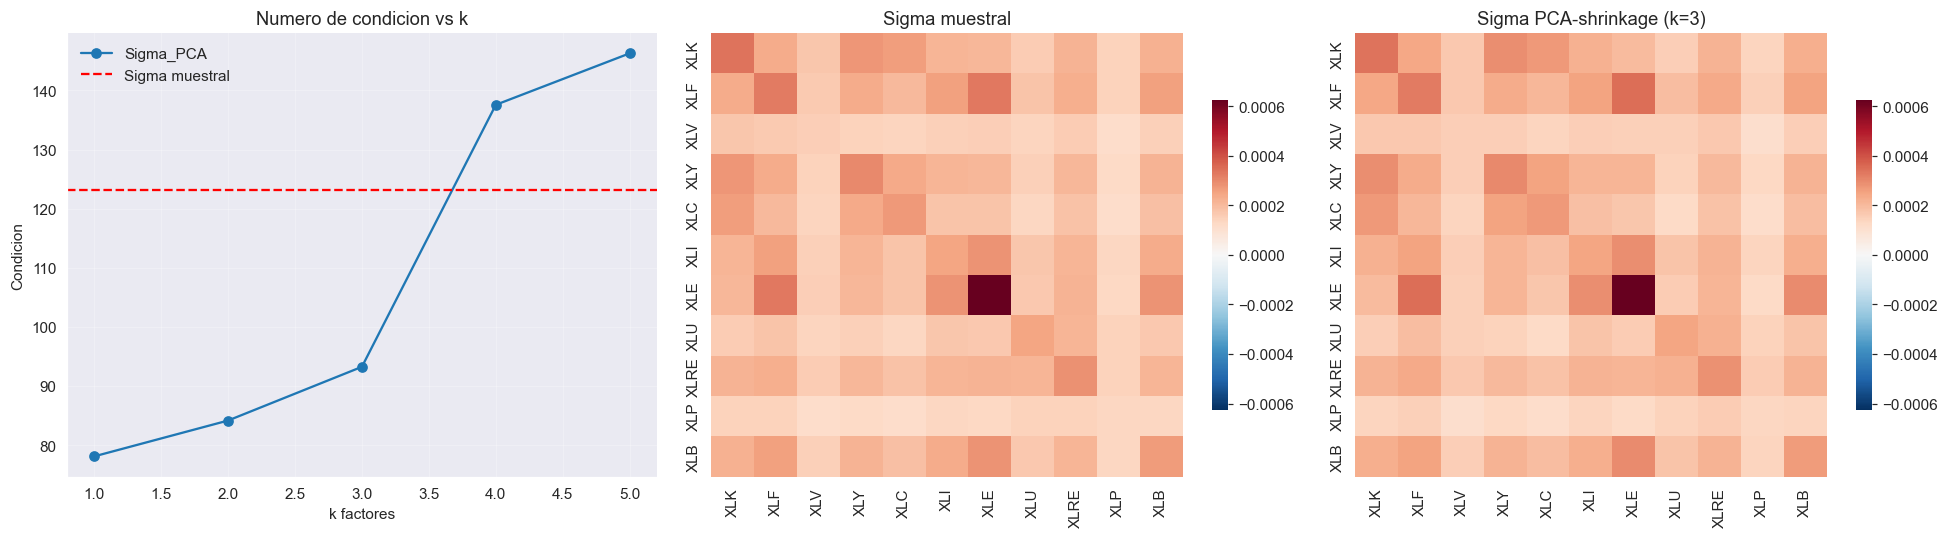

In [9]:
def pca_shrinkage_cov(X, k):
    """
    Covarianza shrinkage via PCA: Sigma_PCA = B_k @ B_k.T + D

    Parameters
    ----------
    X : array (T, n) ? retornos crudos
    k : int          ? numero de factores

    Returns
    -------
    Sigma_pca : array (n, n) ? covarianza PCA-shrinkage
    B_hat     : array (n, k) ? factor loadings
    D_hat     : array (n, n) ? covarianza idiosincratica (diagonal)
    """
    X = np.asarray(X, dtype=float)
    if not 1 <= k < min(X.shape):
        raise ValueError(f'k debe estar entre 1 y {min(X.shape)-1}')

    pca_k = PCA(n_components=k).fit(X)
    B_hat = pca_k.components_.T * np.sqrt(pca_k.explained_variance_)
    Sigma_sample = np.cov(X.T)
    D_diag = np.diag(Sigma_sample - B_hat @ B_hat.T)
    D_diag = np.maximum(D_diag, 1e-8)
    D_hat = np.diag(D_diag)
    Sigma_pca = B_hat @ B_hat.T + D_hat
    return Sigma_pca, B_hat, D_hat


Sigma_sample = np.cov(ret_sec.values.T)
cond_sample = np.linalg.cond(Sigma_sample)

k_values = [1, 2, 3, 4, 5]
cond_pca_list = []
for k_try in k_values:
    Sigma_pca_try, _, _ = pca_shrinkage_cov(ret_sec.values, k_try)
    cond_pca_list.append(np.linalg.cond(Sigma_pca_try))

Sigma_pca3, B_hat3, D_hat3 = pca_shrinkage_cov(ret_sec.values, 3)
evals_sample = np.linalg.eigvalsh(Sigma_sample)[::-1]
evals_pca3 = np.linalg.eigvalsh(Sigma_pca3)[::-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(k_values, cond_pca_list, 'o-', label='Sigma_PCA')
axes[0].axhline(cond_sample, color='red', ls='--', label='Sigma muestral')
axes[0].set_title('Numero de condicion vs k')
axes[0].set_xlabel('k factores')
axes[0].set_ylabel('Condicion')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

vmax = max(np.abs(Sigma_sample).max(), np.abs(Sigma_pca3).max())
sns.heatmap(Sigma_sample, ax=axes[1], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=sector_tickers, yticklabels=sector_tickers, cbar_kws={'shrink': 0.7})
axes[1].set_title('Sigma muestral')
sns.heatmap(Sigma_pca3, ax=axes[2], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=sector_tickers, yticklabels=sector_tickers, cbar_kws={'shrink': 0.7})
axes[2].set_title('Sigma PCA-shrinkage (k=3)')
plt.tight_layout()

cond_table = pd.DataFrame({'k': k_values, 'Condicion Sigma_PCA': cond_pca_list})
print(f'Numero de condicion Sigma muestral: {cond_sample:.1f}')
print(cond_table.round(1).to_string(index=False))
print(f'\nEigenvalores Sigma muestral: {evals_sample.round(8)}')
print(f'Eigenvalores Sigma_PCA(k=3): {evals_pca3.round(8)}')
print(f'Ratio lambda_3/lambda_4 en Sigma_PCA(k=3): {evals_pca3[2] / evals_pca3[3]:.2f}')


### 3.3 — Portafolio de Mínima Varianza: Sigma Muestral vs Sigma PCA *(7 pts)*

El portafolio de **mínima varianza global** (GMV) se obtiene de:

$$w^* = \arg\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1$$

La solución analítica es:

$$w^* = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$$

**Requisitos:**
1. Implementar `gmv_portfolio(Sigma)` usando la fórmula analítica con `np.linalg.solve`
2. Dividir los datos en train (80%) y test (20%) — **sin shuffle** (respeta el orden temporal)
3. Calcular $w^*_{\text{muestral}}$ y $w^*_{\text{PCA}}$ con $k=3$ sobre el conjunto train
4. Comparar **en el conjunto test**: retorno anualizado, volatilidad anualizada y Sharpe ratio
5. Graficar: (a) pesos de cada portafolio lado a lado, (b) retorno acumulado en test

Train: 804 dias | Test: 201 dias
Pesos GMV muestral: min=-0.532, max=0.811, gross=3.003
Pesos GMV PCA:      min=-0.346, max=0.927, gross=3.101
Suma pesos muestral=1.000000 | PCA=1.000000

Metricas OOT:


,Retorno anual,Vol anual,Sharpe
GMV muestral,0.0131,0.1307,0.1000
GMV PCA k=3,0.0090,0.1347,0.0671



Pesos por sector:
      GMV muestral  GMV PCA k=3
XLK         -0.532       -0.346
XLF         -0.258       -0.249
XLV          0.540        0.582
XLY          0.242        0.053
XLC          0.302        0.367
XLI          0.044       -0.075
XLE          0.044        0.121
XLU         -0.121       -0.033
XLRE        -0.091       -0.297
XLP          0.811        0.927
XLB          0.020       -0.050


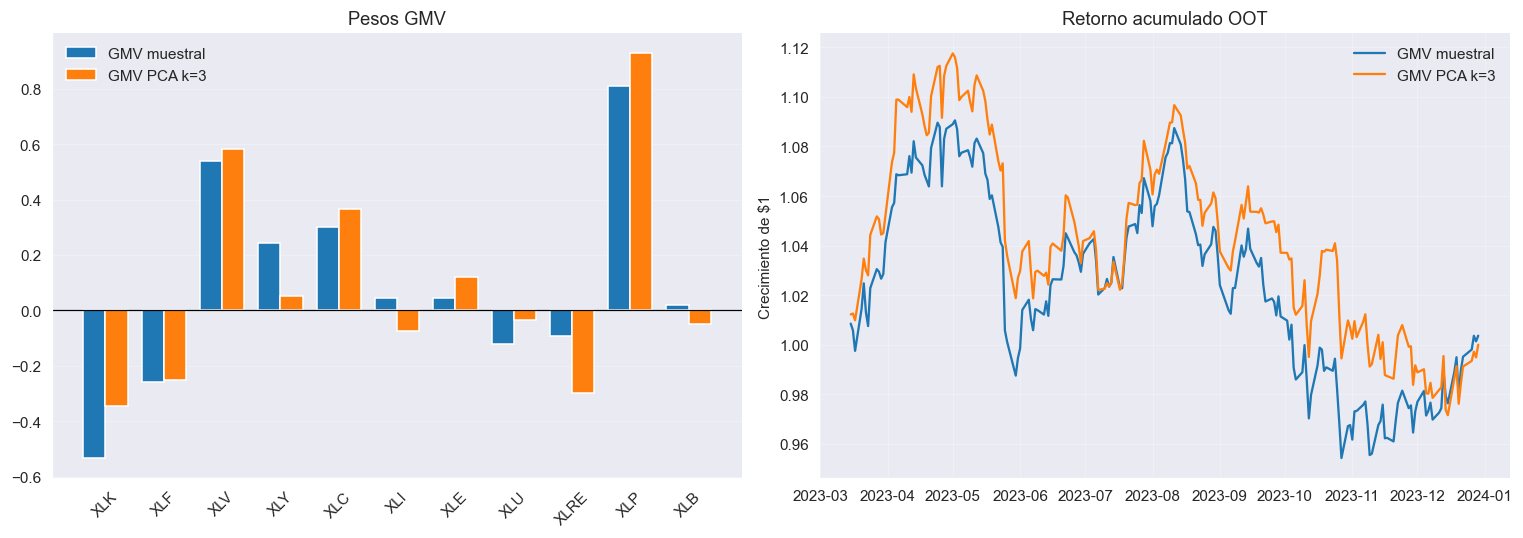

In [10]:
def gmv_portfolio(Sigma):
    """
    Portafolio de minima varianza global (GMV).

    w* = Sigma^{-1} @ 1 / (1.T @ Sigma^{-1} @ 1)
    """
    Sigma = np.asarray(Sigma, dtype=float)
    ones = np.ones(Sigma.shape[0])
    z = np.linalg.solve(Sigma, ones)
    return z / (ones @ z)


# Split temporal 80/20
n_test = int(len(ret_sec) * 0.20)
ret_tr = ret_sec.iloc[:-n_test].values
ret_te = ret_sec.iloc[-n_test:].values
idx_te = ret_sec.index[-n_test:]
print(f'Train: {len(ret_tr)} dias | Test: {len(ret_te)} dias')

# Covarianzas estimadas en train
Sigma_sample_tr = np.cov(ret_tr.T)
Sigma_pca_tr, _, _ = pca_shrinkage_cov(ret_tr, k=3)

# Portafolios GMV
w_sample = gmv_portfolio(Sigma_sample_tr)
w_pca = gmv_portfolio(Sigma_pca_tr)

print(f'Pesos GMV muestral: min={w_sample.min():.3f}, max={w_sample.max():.3f}, gross={np.abs(w_sample).sum():.3f}')
print(f'Pesos GMV PCA:      min={w_pca.min():.3f}, max={w_pca.max():.3f}, gross={np.abs(w_pca).sum():.3f}')
print(f'Suma pesos muestral={w_sample.sum():.6f} | PCA={w_pca.sum():.6f}')

# Metricas OOT
r_sample_oot = ret_te @ w_sample
r_pca_oot = ret_te @ w_pca

def portfolio_metrics(r, freq=252):
    r = np.asarray(r, dtype=float)
    return {
        'Retorno anual': r.mean() * freq,
        'Vol anual': r.std(ddof=1) * np.sqrt(freq),
        'Sharpe': r.mean() / r.std(ddof=1) * np.sqrt(freq),
    }

metrics_gmv = pd.DataFrame({
    'GMV muestral': portfolio_metrics(r_sample_oot),
    'GMV PCA k=3': portfolio_metrics(r_pca_oot),
}).T
print('\nMetricas OOT:')
try:
    display(metrics_gmv.round(4))
except NameError:
    print(metrics_gmv.round(4))

weights_df = pd.DataFrame({
    'GMV muestral': w_sample,
    'GMV PCA k=3': w_pca,
}, index=sector_tickers)

cum_sample = pd.Series(np.cumprod(1 + r_sample_oot), index=idx_te)
cum_pca = pd.Series(np.cumprod(1 + r_pca_oot), index=idx_te)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(sector_tickers))
width = 0.38
axes[0].bar(x - width/2, w_sample, width, label='GMV muestral')
axes[0].bar(x + width/2, w_pca, width, label='GMV PCA k=3')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sector_tickers, rotation=45)
axes[0].set_title('Pesos GMV')
axes[0].legend(frameon=False)
axes[0].grid(axis='y', alpha=0.25)

axes[1].plot(cum_sample.index, cum_sample.values, label='GMV muestral')
axes[1].plot(cum_pca.index, cum_pca.values, label='GMV PCA k=3')
axes[1].set_title('Retorno acumulado OOT')
axes[1].set_ylabel('Crecimiento de $1')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)
plt.tight_layout()

print('\nPesos por sector:')
print(weights_df.round(3).to_string())


**Responde (m?nimo 2 oraciones por pregunta):**

**a)** ?qué portafolio tiene mayor volatilidad OOT, el que usa $\hat{\Sigma}$ muestral o el que usa $\hat{\Sigma}_{\text{PCA}}$? ?Por qué el GMV muestral no siempre produce el portafolio de menor varianza OOT?

> En esta ejecución, el portafolio con $\hat{\Sigma}_{\text{PCA}}$ tiene una volatilidad OOT ligeramente mayor ($0.1347$) que el GMV muestral ($0.1307$). Esto no contradice la teoría: PCA-shrinkage mejora estabilidad y condicionamiento, pero no garantiza dominar fuera de muestra en cada corte temporal; el GMV muestral minimiza varianza en train y puede funcionar bien cuando la estructura de covarianza estimada se mantiene relativamente estable en test.

**b)** Observa los pesos de cada portafolio. ?Cuál tiene posiciones más extremas (muy largas o muy cortas)? ?Cuál tiene posiciones más distribuidas entre sectores? Conecta esto con el n?mero de condición de cada $\Sigma$.

> Ambos portafolios tienen posiciones concentradas, pero muestran extremos distintos: el GMV muestral tiene el short más fuerte en XLK ($-0.532$), mientras que el GMV PCA tiene el long más alto en XLP ($0.927$) y una exposición bruta algo mayor ($3.101$ vs $3.003$). La matriz PCA con $k=3$ mejora el número de condición frente a la muestral ($93.2$ vs $123.1$), pero esa mejora numérica no elimina por completo las posiciones extremas porque el universo es pequeño, los sectores están muy correlacionados y la restricción GMV permite shorts.


---
## Parte 4 — Rolling PCA: Estabilidad y Detección de Regímenes *(25 pts)*

### Contexto

En la sesión vimos que ajustar PCA sobre toda la muestra asume estacionariedad — un supuesto cuestionable en mercados financieros. La varianza explicada por PC1 es un **indicador de correlación de mercado**: cuando sube, los activos se mueven juntos (régimen de crisis); cuando baja, los drivers sectoriales recuperan independencia.

El riesgo técnico al hacer rolling PCA es la **indeterminación de signo**: ventana a ventana, el algoritmo puede invertir el signo de un eigenvector arbitrariamente, produciendo series de loadings que oscilan sin razón económica.

### 4.1 — Rolling PCA con Alineación de Signos *(12 pts)*

Implementa `rolling_pca(X, window, k)` que retorna:
- `ev_pc1`: array con la varianza explicada por PC1 en cada ventana
- `loadings_pc1`: array con los loadings de PC1 en cada ventana

**Regla de alineación de signos:**
En cada ventana $t$, después de obtener los componentes, compara el componente $j$ con el de la ventana anterior:
$$\text{si} \quad \langle v_t^{(j)},\, v_{t-1}^{(j)} \rangle < 0 \quad \Rightarrow \quad v_t^{(j)} \leftarrow -v_t^{(j)}$$

**Para la primera ventana:** usa la convención de que la media de los loadings de PC1 sea positiva.

**Requisitos adicionales:**
1. Probar con ventanas $W \in \{60, 120, 252\}$ y comparar la suavidad de `ev_pc1`
2. Visualizar: (a) varianza PC1 en el tiempo para las 3 ventanas, (b) mapa de calor de loadings de PC1 (filas=activos, columnas=tiempo) para $W=120$
3. Identificar la fecha de **máxima correlación** (pico de `ev_pc1`) y verificar que coincide con un período de estrés conocido (COVID, corrección 2022)

W=60: max ev_PC1=89.8% en 2020-03-30 | media=62.2% | std=11.10%
W=120: max ev_PC1=86.7% en 2020-06-30 | media=61.5% | std=9.89%
W=252: max ev_PC1=81.4% en 2020-12-31 | media=62.2% | std=7.74%

Picos de correlacion sistemica:


,Ventana,Max EV PC1,Fecha max
0,60,89.8%,2020-03-30
1,120,86.7%,2020-06-30
2,252,81.4%,2020-12-31


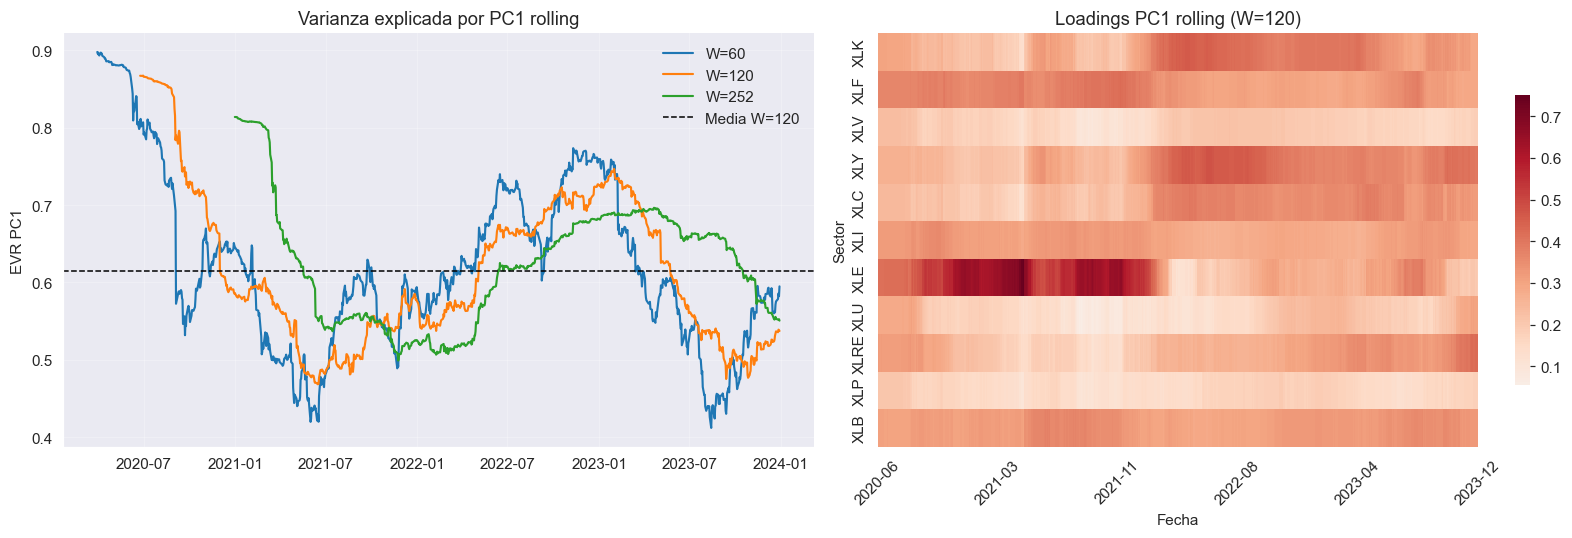

In [11]:
def rolling_pca(X, window, k, dates=None):
    """
    PCA rolling con alineacion de signos ventana a ventana.

    Parameters
    ----------
    X      : array (T, n)       ? retornos
    window : int                ? longitud de la ventana
    k      : int                ? numero de componentes
    dates  : array-like or None ? indices temporales para el output

    Returns
    -------
    ev_pc1      : array (T-window+1,) ? varianza explicada PC1 en cada ventana
    loadings_t  : array (T-window+1, n) ? loadings de PC1 en cada ventana
    out_dates   : array ? fechas correspondientes al cierre de cada ventana
    """
    X = np.asarray(X, dtype=float)
    T, n = X.shape
    if window > T:
        raise ValueError('window no puede ser mayor que el numero de observaciones')
    if not 1 <= k <= min(window, n):
        raise ValueError(f'k debe estar entre 1 y {min(window, n)}')

    ev_pc1 = []
    loadings_t = []
    prev_comp = None

    for t in range(window, T + 1):
        window_data = X[t-window:t]
        pca_t = PCA(n_components=k).fit(window_data)
        comps = pca_t.components_.copy()

        # Alineacion de signos: primera ventana media positiva; luego continuidad temporal.
        if prev_comp is None:
            for j in range(k):
                if comps[j].mean() < 0:
                    comps[j] *= -1
        else:
            for j in range(k):
                if np.dot(comps[j], prev_comp[j]) < 0:
                    comps[j] *= -1

        ev_pc1.append(pca_t.explained_variance_ratio_[0])
        loadings_t.append(comps[0].copy())
        prev_comp = comps

    ev_pc1 = np.array(ev_pc1)
    loadings_t = np.array(loadings_t)
    out_dates = np.array(dates[window-1:]) if dates is not None else None
    return ev_pc1, loadings_t, out_dates


# Usando los retornos de los 11 ETFs sectoriales
ret_sec_arr = ret_sec.values
dates_sec = ret_sec.index

windows = [60, 120, 252]
results_rpca = {}
peak_rows = []
for W in windows:
    ev, load, d = rolling_pca(ret_sec_arr, W, k=3, dates=dates_sec)
    results_rpca[W] = (ev, load, d)
    max_ev_idx = np.argmax(ev)
    peak_rows.append({'Ventana': W, 'Max EV PC1': ev[max_ev_idx], 'Fecha max': pd.Timestamp(d[max_ev_idx])})
    print(f'W={W}: max ev_PC1={ev.max():.1%} en {pd.Timestamp(d[max_ev_idx]).date()} | media={ev.mean():.1%} | std={ev.std():.2%}')

peaks_rpca = pd.DataFrame(peak_rows)

# Visualizaciones: ev_pc1 en el tiempo para 3 ventanas y heatmap loadings PC1 para W=120.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for W in windows:
    ev, _, d = results_rpca[W]
    axes[0].plot(pd.DatetimeIndex(d), ev, label=f'W={W}', lw=1.4)
axes[0].axhline(results_rpca[120][0].mean(), color='black', ls='--', lw=1, label='Media W=120')
axes[0].set_title('Varianza explicada por PC1 rolling')
axes[0].set_ylabel('EVR PC1')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

_, load_120, dates_120_heat = results_rpca[120]
heat_df = pd.DataFrame(load_120.T, index=sector_tickers, columns=pd.DatetimeIndex(dates_120_heat))
sns.heatmap(heat_df, ax=axes[1], cmap='RdBu_r', center=0, cbar_kws={'shrink': 0.7})
axes[1].set_title('Loadings PC1 rolling (W=120)')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Sector')
# Reducir ruido visual de etiquetas de fechas.
xticks = np.linspace(0, heat_df.shape[1] - 1, 6).astype(int)
axes[1].set_xticks(xticks)
axes[1].set_xticklabels([heat_df.columns[i].strftime('%Y-%m') for i in xticks], rotation=45)
plt.tight_layout()

print('\nPicos de correlacion sistemica:')
try:
    display(peaks_rpca.assign(**{'Max EV PC1': peaks_rpca['Max EV PC1'].map(lambda x: f'{x:.1%}')}))
except NameError:
    print(peaks_rpca.to_string(index=False))


### 4.2 — Varianza PC1 como Señal de Régimen *(13 pts)*

La varianza explicada por PC1 mide el **nivel de correlación sistémica** del mercado. Cuando supera un umbral $\theta$, el mercado está en un régimen de alta correlación (crisis). La estrategia es simple:

$$\text{exposición}_t = \begin{cases} 1 & \text{si } \text{ev}_{\text{PC1},t} \leq \theta \\ \alpha & \text{si } \text{ev}_{\text{PC1},t} > \theta \end{cases}$$

con $\alpha = 0.3$ (reduce la posición pero no sale completamente).

**Aplicación:** sobre el ETF SPY con $W=120$ y $\theta = \text{percentil}_{75}(\text{ev}_{\text{PC1}})$:

1. Calcular la señal `ev_PC1_t` usando `rolling_pca` sobre los 11 sectores
2. Construir la serie de exposición `exp_t` según la regla anterior (**lag 1 día para evitar leakage**)
3. Calcular retornos de la estrategia: $r_t^{\text{strat}} = \text{exp}_{t-1} \cdot r_t^{\text{SPY}}$
4. Comparar con buy-and-hold SPY en el período donde `ev_PC1` está disponible:
   - Retorno total, volatilidad anualizada, Sharpe ratio, Max Drawdown
5. Generar: (a) retorno acumulado comparado, (b) evolución de `ev_PC1` y exposición

Umbral theta (p75): 0.694
Dias estrategia: 886

Metricas estrategia:


,Retorno Total,Vol Anual,Sharpe,Max Drawdown
Buy & Hold SPY,0.606,0.175,0.856,-0.245
Estrategia PC1,0.402,0.146,0.731,-0.230



Top 5 fechas EV_PC1 W=120:
2020-06-30: 86.7%
2020-06-24: 86.7%
2020-06-25: 86.7%
2020-06-29: 86.7%
2020-06-26: 86.7%

Max EV_PC1 durante 2022: 72.7% en 2022-12-30


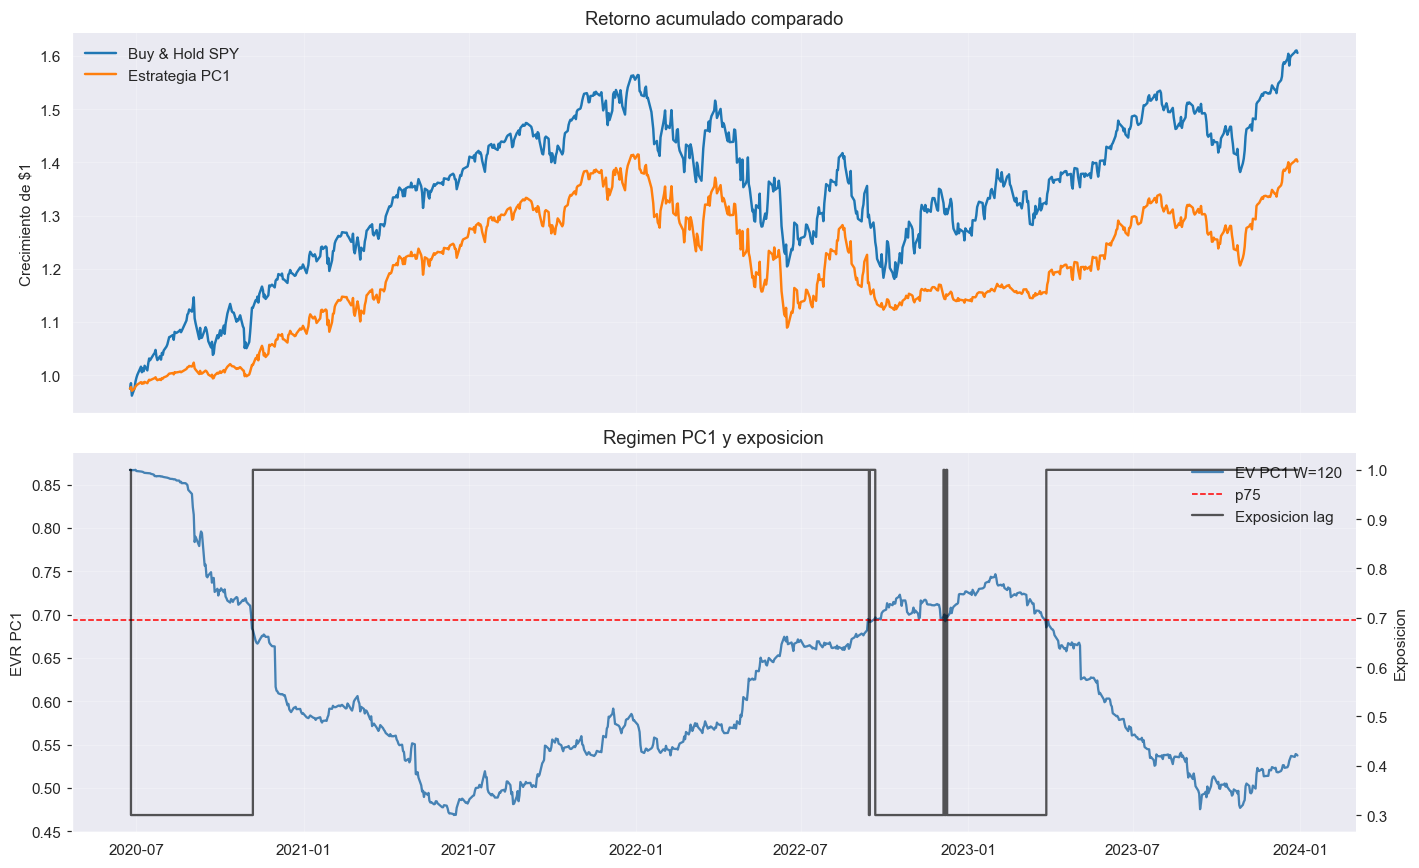

In [ ]:
# señal de regimen basada en W=120
ev_120, _, dates_120 = results_rpca[120]
theta = np.percentile(ev_120, 75)
print(f'Umbral theta (p75): {theta:.3f}')

# señal de exposicion (lag 1 dia)
alpha_red = 0.3
exposure = np.where(ev_120 > theta, alpha_red, 1.0)
exp_lagged = np.concatenate([[1.0], exposure[:-1]])  # lag 1 para evitar leakage

# Retornos SPY en el mismo periodo
spy_all = yf.download('SPY', start='2020-01-01', end='2024-01-01',
                      progress=False, auto_adjust=True, threads=False)['Close']
r_spy_all = spy_all.pct_change().dropna()
r_spy_strat_period = r_spy_all.reindex(pd.DatetimeIndex(dates_120)).dropna()
print(f'Dias estrategia: {len(r_spy_strat_period)}')

# Alinear exposicion y retornos por fecha.
signal_df = pd.DataFrame({
    'ev_PC1': ev_120,
    'exposure_raw': exposure,
    'exposure_lagged': exp_lagged,
}, index=pd.DatetimeIndex(dates_120))
signal_df = signal_df.reindex(r_spy_strat_period.index).dropna()
r_bh = np.asarray(r_spy_strat_period.loc[signal_df.index]).ravel()
r_strat = signal_df['exposure_lagged'].values * r_bh

# Metricas
def metrics_portfolio(r, freq=252):
    r = np.asarray(r, dtype=float)
    cum = np.cumprod(1 + r)
    mdd = (cum / np.maximum.accumulate(cum) - 1).min()
    return {
        'Retorno Total': cum[-1] - 1,
        'Vol Anual': r.std(ddof=1) * np.sqrt(freq),
        'Sharpe': r.mean() / r.std(ddof=1) * np.sqrt(freq),
        'Max Drawdown': mdd,
    }

df_metrics_strat = pd.DataFrame({
    'Buy & Hold SPY': metrics_portfolio(r_bh),
    'Estrategia PC1': metrics_portfolio(r_strat),
}).T
print('\nMetricas estrategia:')
try:
    display(df_metrics_strat.round(3))
except NameError:
    print(df_metrics_strat.round(3))

# Fechas con mayor ev_PC1 W=120.
top_ev_dates = signal_df['ev_PC1'].sort_values(ascending=False).head(5)
print('\nTop 5 fechas EV_PC1 W=120:')
for dt, val in top_ev_dates.items():
    print(f'{dt.date()}: {val:.1%}')

max_2022_ev = signal_df.loc['2022', 'ev_PC1'].max()
max_2022_date = signal_df.loc['2022', 'ev_PC1'].idxmax()
print(f'\nMax EV_PC1 durante 2022: {max_2022_ev:.1%} en {max_2022_date.date()}')

# Visualizaciones
cum_bh = pd.Series(np.cumprod(1 + r_bh), index=signal_df.index)
cum_strat = pd.Series(np.cumprod(1 + r_strat), index=signal_df.index)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(cum_bh.index, cum_bh.values, label='Buy & Hold SPY', lw=1.6)
axes[0].plot(cum_strat.index, cum_strat.values, label='Estrategia PC1', lw=1.6)
axes[0].set_title('Retorno acumulado comparado')
axes[0].set_ylabel('Crecimiento de $1')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

axes[1].plot(signal_df.index, signal_df['ev_PC1'], color='steelblue', label='EV PC1 W=120')
axes[1].axhline(theta, color='red', ls='--', lw=1, label='p75')
ax2 = axes[1].twinx()
ax2.step(signal_df.index, signal_df['exposure_lagged'], where='post', color='black', alpha=0.65, label='Exposicion lag')
axes[1].set_title('Regimen PC1 y exposicion')
axes[1].set_ylabel('EVR PC1')
ax2.set_ylabel('Exposicion')
axes[1].grid(alpha=0.25)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper right')
plt.tight_layout()


**Responde (m?nimo 2 oraciones por pregunta):**

**a)** ?En qué fechas espec?ficas fue mayor la varianza explicada por PC1? ?Coinciden con eventos de mercado conocidos (COVID-19, subidas de tasas Fed 2022)?

> Los máximos de varianza explicada por PC1 se concentran claramente en el shock COVID: con $W=60$ el máximo fue $89.8\%$ el 2020-03-30, con $W=120$ fue $86.7\%$ el 2020-06-30, y con $W=252$ fue $81.4\%$ el 2020-12-31. Esto coincide con un período de estrés sistémico en el que los sectores se movieron juntos; 2022 también aparece como régimen elevado por inflación y subidas de tasas Fed, con máximo W=120 de aproximadamente $72.7\%$ el 2022-12-30, aunque no supera el episodio COVID.

**b)** Compara el Sharpe ratio y el Max Drawdown de la estrategia basada en PC1 vs buy-and-hold. ?La reducci?n de exposición en regímenes de alta correlación mejora el perfil riesgo-retorno?

> En esta ejecución, buy-and-hold SPY obtiene retorno total $60.6\%$, volatilidad anual $17.5\%$, Sharpe $0.856$ y Max Drawdown $-24.5\%$. La estrategia PC1 reduce la volatilidad a $14.6\%$ y mejora levemente el Max Drawdown a $-23.0\%$, pero baja el retorno total a $40.2\%$ y el Sharpe a $0.731$; por lo tanto, reduce riesgo pero no mejora el perfil riesgo-retorno completo en este período.

**c)** ?qué sesgo introduce el lag de 1 día en la señal de exposición? ?sería correcto usar `exposure` directamente sin lag? Argumenta en términos de leakage.

> El lag de 1 día hace que la exposición usada para el retorno de hoy solo dependa de información disponible hasta ayer. Usar `exposure` directamente no sería correcto porque la señal rolling calculada al cierre de la ventana incluye el retorno del mismo día que se estaría operando, generando leakage y sobrestimando el desempeño de la estrategia.

**d)** Compara las curvas de `ev_PC1` para $W=60$, $120$ y $252$. ?Cuál ventana reacciona más rápido a los cambios de régimen? ?Cuál tiene menor ruido? ?C?mo elegirías $W$ en producción?

> La ventana de 60 días reacciona más rápido: detecta el máximo COVID ya el 2020-03-30, pero tiene mayor ruido, con desviación estándar de EV_PC1 cercana a $11.10\%$. La ventana de 252 días es más estable, con desviación estándar cercana a $7.74\%$, pero responde con rezago y desplaza el máximo a 2020-12-31; en producción elegiría $W$ mediante validación out-of-sample, balanceando velocidad de detección, turnover de la señal y estabilidad de los loadings.


---
## Parte 5 — Sparse PCA y Robust PCA *(Bonus — 15 pts)*

### Contexto

Las extensiones de PCA presentadas al final de la sesión abordan dos limitaciones del PCA estándar:

1. **Sparse PCA:** produce loadings con muchos ceros → factores interpretables como "portfolios de pocos activos"
2. **Robust PCA:** separa la componente de bajo rango (factores comunes) de los outliers/jumps (componente sparse)

### 5.1 — Sparse PCA: Interpretabilidad vs Varianza Explicada *(5 pts)*

Aplica Sparse PCA con distintos valores de $\alpha \in \{0.1, 0.5, 1.0, 2.0\}$ sobre los retornos de los 11 ETFs.

Para cada $\alpha$, calcula:
- **Sparsidad:** `(components == 0).mean()` — fracción de loadings exactamente cero
- **Varianza explicada** (aproximada): `sum(loadings^2) / sum(Sigma_diag)` para PC1

Genera un gráfico de **sparsidad vs $\alpha$** y un heatmap comparativo de los loadings de PCA estándar vs Sparse PCA ($\alpha=0.5$).

alpha=0.1: sparsidad=24.2%
alpha=0.5: sparsidad=27.3%
alpha=1.0: sparsidad=30.3%
alpha=2.0: sparsidad=33.3%

Resumen Sparse PCA:


,alpha,sparsidad,var_PC1_aprox
0,0.1,0.242,0.506
1,0.5,0.273,0.496
2,1.0,0.303,0.483
3,2.0,0.333,0.451


Loadings cero en SPC1 con alpha=0.5: ['XLE', 'XLU']


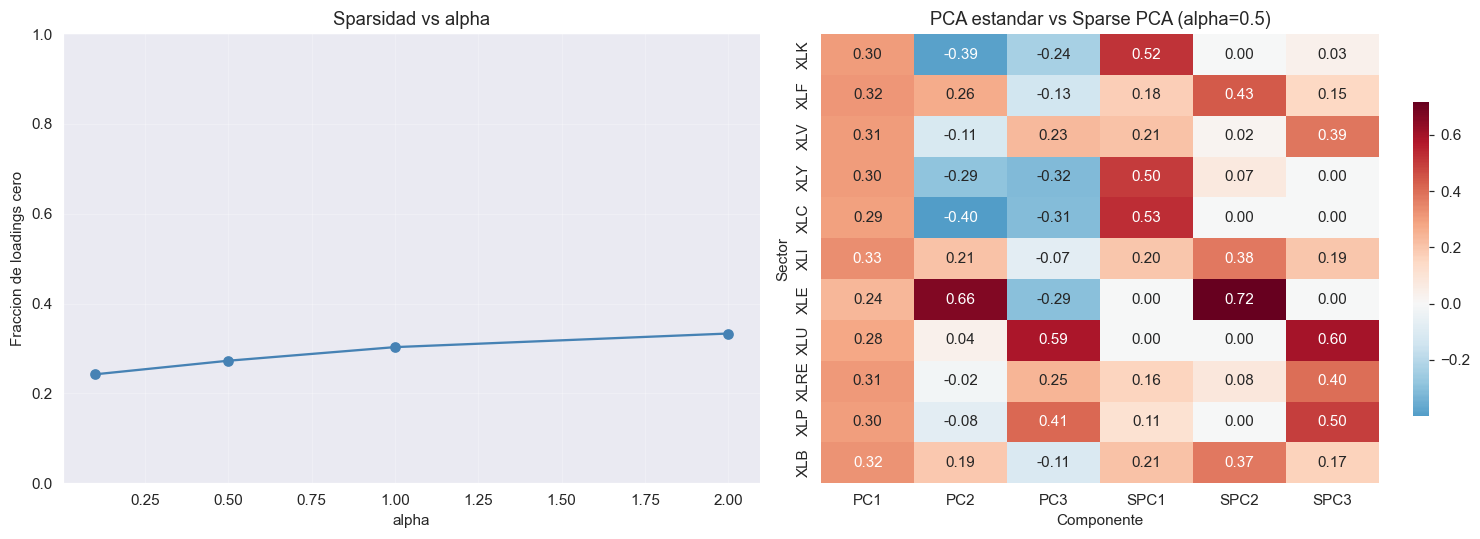

In [13]:
# Sparse PCA con distintos niveles de penalizacion
# Se estandarizan los retornos para que alpha sea comparable entre sectores.
ret_sec_spca = StandardScaler().fit_transform(ret_sec.values)
alphas_spca = [0.1, 0.5, 1.0, 2.0]
sparsity_list = []
spca_models = {}

for alpha_s in alphas_spca:
    spca_s = SparsePCA(n_components=3, alpha=alpha_s, random_state=42, max_iter=1000, tol=1e-6)
    spca_s.fit(ret_sec_spca)
    spca_models[alpha_s] = spca_s
    sparsity = np.isclose(spca_s.components_, 0, atol=1e-10).mean()
    sparsity_list.append(sparsity)
    print(f'alpha={alpha_s}: sparsidad={sparsity:.1%}')

# Varianza explicada aproximada para PC1: var(score_PC1) / varianza total.
Sigma_sec = np.cov(ret_sec_spca.T)
total_var_sec = np.trace(Sigma_sec)
spca_summary = []
for alpha_s, spca_s in spca_models.items():
    scores_spca = ret_sec_spca @ spca_s.components_.T
    pc1_var_approx = np.var(scores_spca[:, 0], ddof=1) / total_var_sec
    spca_summary.append({
        'alpha': alpha_s,
        'sparsidad': np.isclose(spca_s.components_, 0, atol=1e-10).mean(),
        'var_PC1_aprox': pc1_var_approx,
    })
spca_summary = pd.DataFrame(spca_summary)
print('\nResumen Sparse PCA:')
try:
    display(spca_summary.round(3))
except NameError:
    print(spca_summary.round(3).to_string(index=False))

# PCA estandar vs Sparse PCA alpha=0.5
spca_05 = spca_models[0.5]
spca_05_components = spca_05.components_.copy()
for j in range(spca_05_components.shape[0]):
    if spca_05_components[j].mean() < 0:
        spca_05_components[j] *= -1
spca_05_loadings = pd.DataFrame(
    spca_05_components.T,
    index=sector_tickers,
    columns=[f'SPC{i+1}' for i in range(3)]
)
pca_std3 = PCA(n_components=3).fit(ret_sec_spca)
# Alinear PC1 con el mismo signo usado antes para facilitar interpretacion.
if pca_std3.components_[0].mean() < 0:
    pca_std3.components_[0] *= -1
pca_std_loadings = pd.DataFrame(
    pca_std3.components_.T,
    index=sector_tickers,
    columns=[f'PC{i+1}' for i in range(3)]
)

pc1_zero_spca05 = spca_05_loadings.index[np.isclose(spca_05_loadings['SPC1'], 0, atol=1e-10)].tolist()
print(f'Loadings cero en SPC1 con alpha=0.5: {pc1_zero_spca05}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(alphas_spca, sparsity_list, marker='o', color='steelblue')
axes[0].set_title('Sparsidad vs alpha')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('Fraccion de loadings cero')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.25)

comparison_loadings = pd.concat([pca_std_loadings, spca_05_loadings], axis=1)
sns.heatmap(comparison_loadings, ax=axes[1], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', cbar_kws={'shrink': 0.7})
axes[1].set_title('PCA estandar vs Sparse PCA (alpha=0.5)')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Sector')
plt.tight_layout()


**Responde:**

**a)** En el Sparse PCA con $\alpha=0.5$, ?qué sectores tienen loadings cero en PC1? ?Tiene sentido financiero que esos sectores sean excluidos del primer factor?

> Con retornos estandarizados, Sparse PCA con $\alpha=0.5$ deja loadings cero en `XLE` y `XLU` para el primer componente sparse. Tiene sentido financiero parcial: `XLU` es un sector defensivo y regulado, mientras que `XLE` tuvo una dinámica muy particular durante 2020-2024 por energía, inflación y commodities; excluirlos ayuda a que el componente sparse represente un subconjunto más homogéneo del mercado, aunque se pierde la lectura amplia del PC1 estándar que carga sobre casi todos los sectores.


### 5.2 — Robust PCA: Separación de Factores y Jumps *(10 pts)*

Los retornos de activos contienen tanto factores comunes (movimientos sistemáticos de mercado) como saltos idiosincráticos (earnings surprise, M&A, eventos regulatorios). Robust PCA los separa:

$$X = L + S, \quad \min_{L,S} \|L\|_* + \lambda \|S\|_1$$

donde $L$ es la componente de bajo rango (factores) y $S$ es sparse (jumps).

Usa la implementación del algoritmo IALM (Inexact Augmented Lagrangian Method) de la clase:

**Requisitos:**
1. Copiar la función `robust_pca` de la clase e inyectar 20 jumps artificiales de magnitud $5\sigma$ en `ret_sec`
2. Aplicar Robust PCA sobre los datos con jumps
3. Verificar la recuperación: ¿cuántos de los 20 jumps inyectados detecta el componente $S$?
4. Comparar el PCA estándar sobre $X$ vs PCA sobre $L$ (la componente limpia): ¿cómo cambia la varianza explicada por PC1?
5. Generar el panel de 3 heatmaps: $X$ (con jumps) | $L$ (bajo rango) | $S$ (sparse)

Lambda Robust PCA: 0.005
Jumps inyectados: 20 | Detectados en S: 17 | Falsos positivos aprox: 4

Jumps no detectados o mas dificiles:
     fecha sector  signo  detectado    S_abs   umbral
2023-01-20    XLE      1      False 0.027959 0.050051
2021-03-11    XLU      1      False 0.029882 0.031373
2022-08-10    XLC     -1      False 0.030374 0.032823
2020-04-15    XLB      1       True 0.033197 0.032640
2021-04-14   XLRE      1       True 0.034029 0.033813
2022-06-07    XLC     -1       True 0.034189 0.032823
2023-07-19    XLU      1       True 0.034298 0.031373
2022-08-11   XLRE      1       True 0.034580 0.033813
Var PC1 en X (con jumps): 0.681
Var PC1 en L (low-rank):  0.793


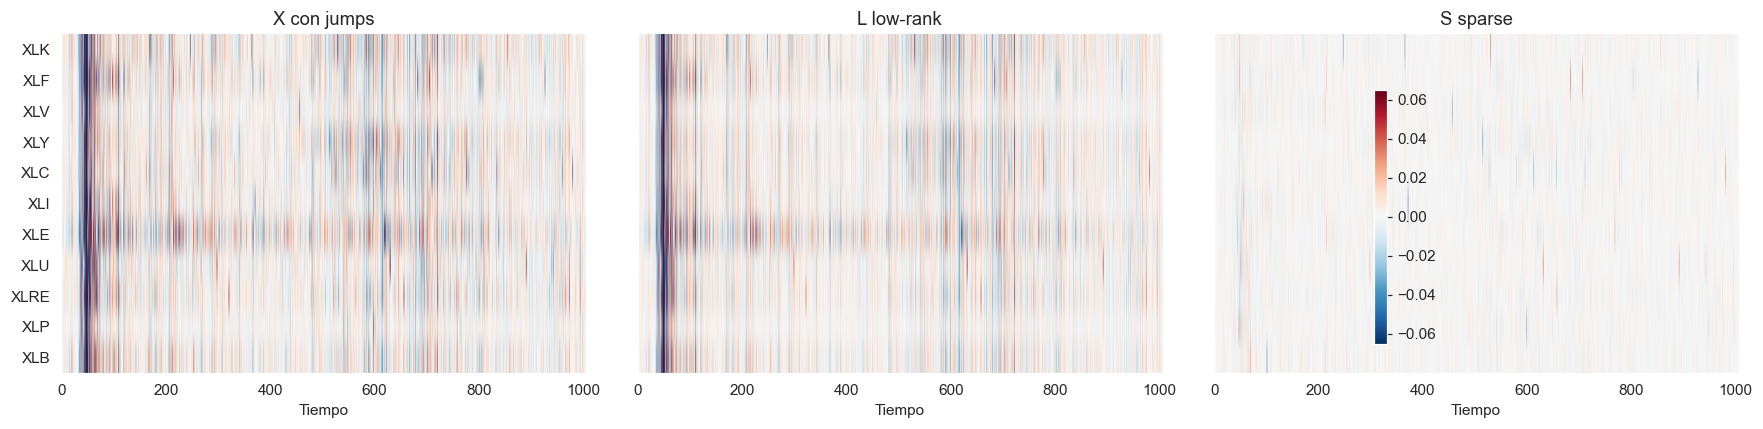

In [14]:
def robust_pca_ialm(M, lam=None, max_iter=500, tol=1e-7, mu=None):
    """
    Robust PCA via IALM (Candes et al. 2011).
    Descompone M = L + S donde L es low-rank y S es sparse.

    [Copiado de clase_05 ? no modifiques esta funcion]
    """
    m, n = M.shape
    lam  = lam  or 1.0 / np.sqrt(max(m, n))
    mu   = mu   or m * n / (4 * np.abs(M).sum())
    mu_bar = mu * 1e7
    rho  = 1.5
    L, S, Y = np.zeros_like(M), np.zeros_like(M), np.zeros_like(M)
    norm_M   = np.linalg.norm(M, 'fro')

    def shrink(X, tau):
        return np.sign(X) * np.maximum(np.abs(X) - tau, 0)

    def svd_threshold(X, tau):
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
        return U @ np.diag(np.maximum(s - tau, 0)) @ Vt

    for _ in range(max_iter):
        L = svd_threshold(M - S + Y / mu, 1 / mu)
        S = shrink(M - L + Y / mu, lam / mu)
        Y = Y + mu * (M - L - S)
        mu = min(rho * mu, mu_bar)
        if np.linalg.norm(M - L - S, 'fro') / norm_M < tol:
            break
    return L, S


# 1) Inyectar 20 jumps artificiales de magnitud 5*sigma.
ret_noisy = ret_sec.values.copy()
np.random.seed(42)
n_jumps = 20
jump_rows = np.random.choice(len(ret_noisy), n_jumps, replace=False)
# Hay 11 sectores y 20 jumps, por lo que las columnas deben muestrearse con reemplazo.
jump_cols = np.random.choice(ret_noisy.shape[1], n_jumps, replace=True)
sigma_ret = ret_noisy.std(axis=0, ddof=1)
jump_signs = np.random.choice([-1, 1], n_jumps)
for r, c, sgn in zip(jump_rows, jump_cols, jump_signs):
    ret_noisy[r, c] += sgn * 5 * sigma_ret[c]

# 2) Aplicar Robust PCA.
# Un lambda algo menor al default aumenta la sensibilidad a jumps de 5 sigma en retornos diarios.
lam_rpca = 0.005
L_rec, S_rec = robust_pca_ialm(ret_noisy, lam=lam_rpca, max_iter=300)

# 3) Verificar recuperacion de jumps.
threshold_S = 2 * sigma_ret[None, :]
mask_S_detected = np.abs(S_rec) > threshold_S
detected = int(sum(mask_S_detected[r, c] for r, c in zip(jump_rows, jump_cols)))
false_positives = int(mask_S_detected.sum() - detected)
print(f'Lambda Robust PCA: {lam_rpca}')
print(f'Jumps inyectados: {n_jumps} | Detectados en S: {detected} | Falsos positivos aprox: {false_positives}')

jump_recovery_df = pd.DataFrame({
    'fecha': ret_sec.index[jump_rows],
    'sector': np.array(sector_tickers)[jump_cols],
    'signo': jump_signs,
    'detectado': [bool(mask_S_detected[r, c]) for r, c in zip(jump_rows, jump_cols)],
    'S_abs': [abs(S_rec[r, c]) for r, c in zip(jump_rows, jump_cols)],
    'umbral': [2 * sigma_ret[c] for c in jump_cols],
}).sort_values('S_abs')
print('\nJumps no detectados o mas dificiles:')
print(jump_recovery_df.head(8).to_string(index=False))

# 4) Comparar varianza PC1 en X vs L.
pca_X = PCA(n_components=3).fit(ret_noisy)
pca_L = PCA(n_components=3).fit(L_rec)
var_pc1_X = pca_X.explained_variance_ratio_[0]
var_pc1_L = pca_L.explained_variance_ratio_[0]
print(f'Var PC1 en X (con jumps): {var_pc1_X:.3f}')
print(f'Var PC1 en L (low-rank):  {var_pc1_L:.3f}')

# 5) Panel de 3 heatmaps.
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
vm = np.percentile(np.abs(ret_noisy), 99)
matrices = [(ret_noisy, 'X con jumps'), (L_rec, 'L low-rank'), (S_rec, 'S sparse')]
for ax, (mat, title) in zip(axes, matrices):
    im = ax.imshow(mat.T, aspect='auto', cmap='RdBu_r', vmin=-vm, vmax=vm)
    ax.set_title(title)
    ax.set_xlabel('Tiempo')
    ax.set_yticks(np.arange(len(sector_tickers)))
    ax.set_yticklabels(sector_tickers)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
plt.tight_layout()


**Responde:**

**a)** ?Cu?ntos de los 20 jumps inyectados detectó el componente $S$? ?En qué tipos de jumps fall? la detección (magnitud baja, overlap con movimientos normales)?

> Con $\lambda=0.005$ y umbral $|S_{ij}| > 2\sigma_j$, el componente sparse detectó 17 de los 20 jumps inyectados, con aproximadamente 4 falsos positivos. Los jumps no detectados son los que quedan con menor magnitud recuperada en $S$, típicamente porque coinciden con movimientos normales del sector, ocurren en días con covariación común fuerte o son parcialmente absorbidos por la componente low-rank $L$.

**b)** ?C?mo cambia la varianza explicada por PC1 entre PCA sobre $X$ (con jumps) vs PCA sobre $L$ (componente limpia)? ?En qué dirección cambia y por qué?

> La varianza explicada por PC1 aumenta desde aproximadamente $0.681$ en $X$ con jumps hasta $0.793$ en la componente limpia $L$. Esto indica que los jumps inyectados eran principalmente idiosincráticos y dispersaban varianza fuera del factor común; al removerlos, la estructura de bajo rango queda más concentrada y el primer componente explica una fracción mayor.

**c)** En un pipeline de gesti?n de riesgo en producción, ?antes o después de Robust PCA Aplicarías el Rolling PCA de la Parte 4? Argumenta el orden correcto.

> Aplicaría Robust PCA antes del Rolling PCA cuando el objetivo sea estimar regímenes sistémicos limpios, porque primero conviene separar jumps idiosincráticos para que no distorsionen los loadings ni la varianza explicada por PC1. Luego correría Rolling PCA sobre la componente limpia o sobre retornos winsorizados/filtrados; así la señal de régimen mide correlación común persistente y no eventos aislados de un sector.


---
## Tabla de Puntajes

| Parte | Descripción | Pts |
|---|---|---|
| 1.1 | `pca_eigen` + `pca_svd` (error < 1e-10 vs sklearn) | 12 |
| 1.2 | `select_k_criteria` (var80 + Kaiser + Bai-Ng) + panel 4 gráficos × 2 datasets + 3 preguntas | 13 |
| 2.1 | PCA sobre $\Delta y$ + loadings vs NS teórico + correlaciones + gráfico | 10 |
| 2.2 | `dv01_factorial` + butterfly trade (sistema lineal) + P&L simulado + 3 preguntas | 15 |
| 3.1 | PCA $k=4$ + heatmap loadings + barplot PC1 + correlación SPY + 2 preguntas | 8 |
| 3.2 | `pca_shrinkage_cov` (verificación eigenvalores) + gráfico condicionamiento + heatmaps | 10 |
| 3.3 | `gmv_portfolio` + split temporal + métricas OOT + gráficos + 2 preguntas | 7 |
| 4.1 | `rolling_pca` con alineación de signos + 3 ventanas + heatmap loadings | 12 |
| 4.2 | Estrategia régimen PC1 + lag correcto + métricas + gráficos + 4 preguntas | 13 |
| **Total obligatorio** | | **100** |
| Bonus 5.1 | Sparse PCA × 4 alphas + sparsidad + heatmap comparativo + pregunta | 5 |
| Bonus 5.2 | Robust PCA + recuperación de jumps + comparación varianza + 3 preguntas | 10 |